#  Analisis Indeks Standar Pencemar Udara (ISPU) DKI Jakarta (2010 - 2025)

## BAGIAN 1 — BUSINESS UNDERSTANDING


### 1.1 Latar Belakang

**ISPU (Indeks Standar Pencemar Udara)** adalah indeks yang digunakan untuk menggambarkan kondisi mutu udara ambien di lokasi dan waktu tertentu yang didasarkan kepada dampak terhadap kesehatan manusia, nilai estetika, dan makhluk hidup lainnya.

ISPU pertama kali ditetapkan melalui **Keputusan Menteri Negara Lingkungan Hidup Nomor: KEP-45/MENLH/10/1997** dan diperbarui melalui **Peraturan Menteri Lingkungan Hidup dan Kehutanan Nomor P.14/MENLH/2020**.

#### Konteks DKI Jakarta
- Jakarta adalah **ibu kota Indonesia** dengan populasi lebih dari **10 juta jiwa** (dan 30 juta di Jabodetabek)
- Jakarta secara konsisten masuk dalam daftar kota dengan **kualitas udara terburuk di Asia Tenggara**
- Polusi udara berdampak pada **kesehatan masyarakat, produktivitas ekonomi, pariwisata, dan citra kota**
- Pemerintah DKI Jakarta mengoperasikan **5 stasiun pemantau kualitas udara** real-time
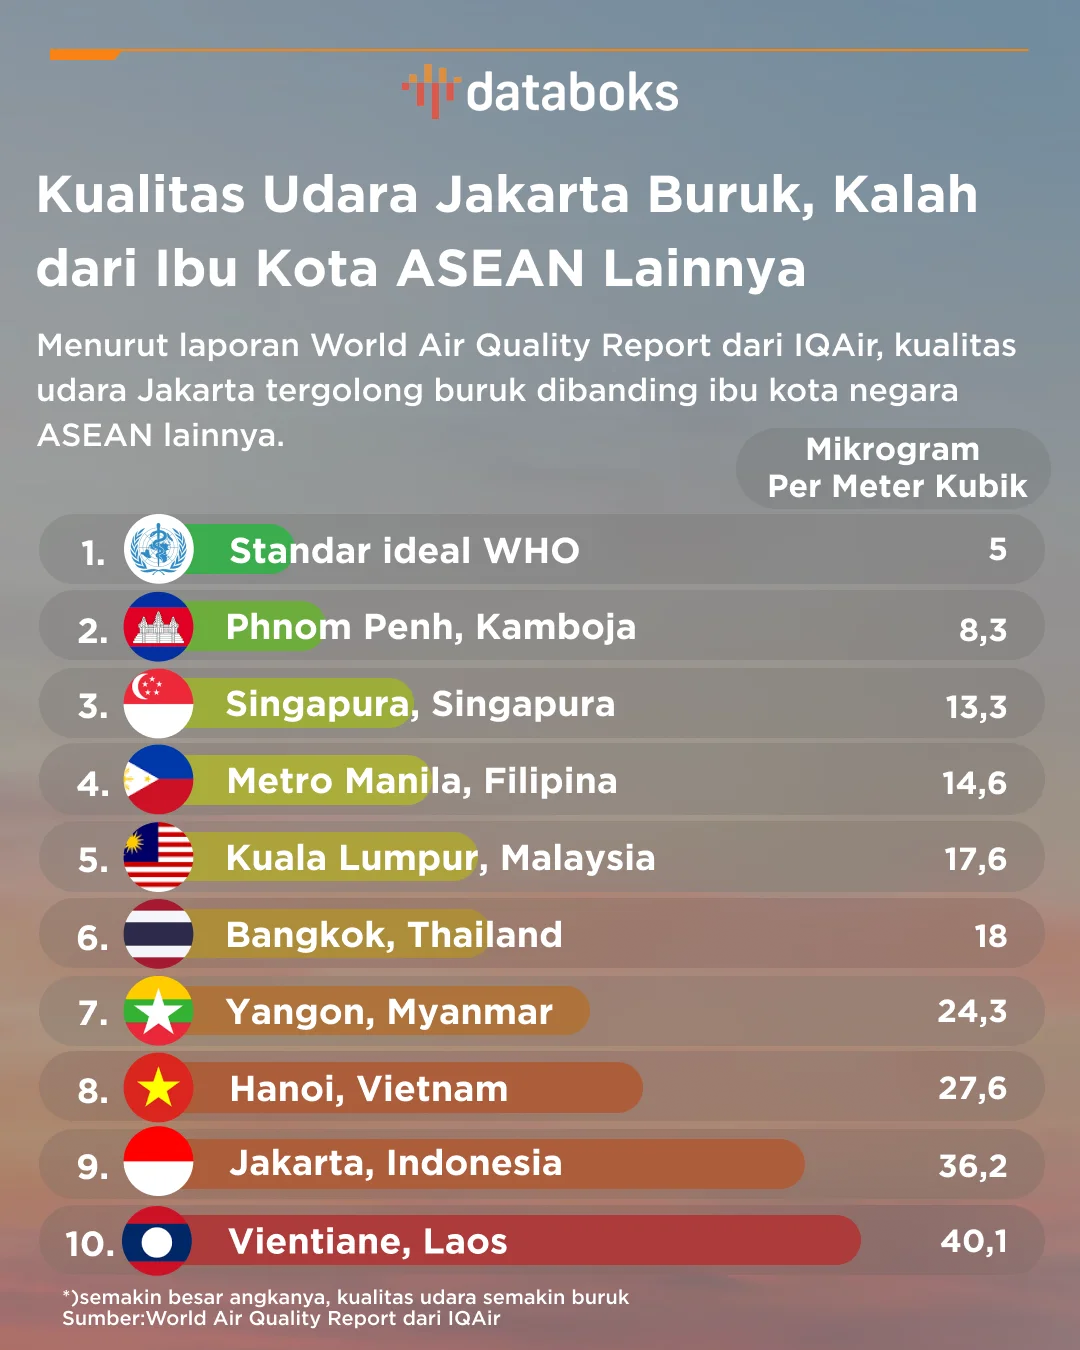
#### Parameter Polutan yang Diukur

| Parameter | Nama Lengkap | Sumber Utama |
|-----------|-------------|--------------|
| **PM2.5** | Partikel Halus (≤2.5 µm) | Kendaraan bermotor, industri, pembakaran |
| **PM10** | Partikel Kasar (≤10 µm) | Debu konstruksi, jalan, industri |
| **SO₂** | Sulfur Dioksida | Pembakaran bahan bakar fosil, industri |
| **CO** | Karbon Monoksida | Kendaraan bermotor, pembakaran tidak sempurna |
| **O₃** | Ozon Troposferik | Reaksi fotokimia (polutan sekunder) |
| **NO₂** | Nitrogen Dioksida | Kendaraan bermotor, pembangkit listrik |

#### Lokasi 5 Stasiun Pemantau

| Kode | Lokasi | Wilayah | Karakteristik |
|------|--------|---------|---------------|
| DKI1 | Bunderan HI | Jakarta Pusat | Kawasan komersial & traffic tinggi |
| DKI2 | Kelapa Gading | Jakarta Utara | Kawasan permukiman & komersial |
| DKI3 | Jagakarsa | Jakarta Selatan | Relatif hijau, residential |
| DKI4 | Lubang Buaya | Jakarta Timur | Kawasan perumahan & industri |
| DKI5 | Kebon Jeruk | Jakarta Barat | Kawasan mixed-use |

### 1.2 Kategori ISPU & Rentang Nilai

Berdasarkan PerMen LHK No. P.14/MENLH/2020:

| Nilai ISPU | Kategori | Warna | Dampak Kesehatan |
|-----------|----------|-------|-----------------|
| 0 – 50 | **BAIK** |  Hijau | Tidak memberikan efek negatif |
| 51 – 100 | **SEDANG** |  Kuning | Tidak berpengaruh pada kesehatan manusia dan hewan, tetapi berpengaruh pada tumbuhan sensitif |
| 101 – 199 | **TIDAK SEHAT** | Oranye | Bersifat merugikan pada manusia, hewan, dan tumbuhan |
| 200 – 299 | **SANGAT TIDAK SEHAT** | Merah | Kualitas udara yang dapat meningkatkan risiko kesehatan pada manusia |
| 300+ | **BERBAHAYA** | Ungu | Tingkat kualitas udara yang berbahaya secara umum |

### 1.3 Problem Statement & Tujuan Analisis

#### Problem Statement
> *"Bagaimana tren kualitas udara DKI Jakarta selama 15 tahun terakhir (2010–2025), faktor apa yang paling berkontribusi terhadap pencemaran, dan bagaimana distribusi kondisi udara antar wilayah serta waktu?"*

#### Tujuan Analisis (Business Goals → Analytic Goals)

| # | Business Goal | Analytic Goal | Metode |
|---|--------------|---------------|--------|
| 1 | Memahami tren kualitas udara jangka panjang | Analisis time series ISPU per tahun | Trend line, rolling mean |
| 2 | Identifikasi polutan dominan | Analisis distribusi parameter `critical` | Frequency analysis, bar chart |
| 3 | Pemetaan wilayah paling tercemar | Perbandingan antar stasiun | Box plot, heatmap |
| 4 | Pola musiman & harian | Deteksi seasonality | Heatmap bulan/musim |
| 5 | Kualitas data untuk modeling | Audit missing values & anomali | Missingness matrix |
| 6 | Baseline untuk prediksi / klasifikasi | EDA fitur target `categori` | Class distribution |

#### Key Analytic Questions
1. Apakah kualitas udara Jakarta membaik atau memburuk dari 2010 ke 2025?
2. Bulan/musim apa yang memiliki kualitas udara terburuk?
3. Stasiun mana yang secara konsisten mencatat nilai ISPU tertinggi?
4. Polutan apa yang paling sering menjadi pencemar kritis?
5. Seberapa besar proporsi hari dengan kategori "Tidak Sehat" atau lebih buruk?
6. Apakah ada korelasi antar polutan?
7. Bagaimana distribusi nilai outlier pada setiap parameter?

### 1.4 Stakeholder & Implikasi

| Stakeholder | Kebutuhan | Output dari Analisis |
|------------|----------|----------------------|
| **Dinas LHK DKI Jakarta** | Monitoring & kebijakan | Tren, hotspot lokasi, pola temporal |
| **Kemenkes RI** | Peringatan dini kesehatan | Proporsi hari berbahaya, threshold |
| **Masyarakat Umum** | Informasi kualitas udara | Dashboard, kategori harian |
| **Peneliti/Akademisi** | Baseline dataset | Statistik deskriptif, korelasi |
| **Media & Jurnalis** | Narasi data | Insight utama, visualisasi |
| **Pemerintah Kota** | Evaluasi kebijakan (ganjil-genap, PPKM) | Tren tahunan, efek COVID-19 2020 |

## BAGIAN 2 — DATA LOADING & DATA UNDERSTANDING

## 2.1 Import Library

In [1]:
# Data Manipulation 
import numpy as np
import pandas as pd

In [2]:
# Visualisasi 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

In [3]:
# Statistik
from scipy import stats


In [4]:
# Konfigurasi Global
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 120)

In [5]:
# Tema visualisasi
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.facecolor' : 'white',
})

In [6]:
ISPU_COLORS = {
    'BAIK'              : '#2ecc71',  
    'SEDANG'            : '#f1c40f',  # kuning
    'TIDAK SEHAT'       : '#e67e22',  # oranye
    'SANGAT TIDAK SEHAT': '#e74c3c',  # merah
    'BERBAHAYA'         : '#8e44ad',  #
    'TIDAK ADA DATA'    : '#95a5a6',  
}

In [7]:
# Urutan kategori (ordinal)
KATEGORI_ORDER = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA', 'TIDAK ADA DATA']

print("Semua library berhasil diimport!")
print(f"NumPy    : v{np.__version__}")
print(f"Pandas   : v{pd.__version__}")
print(f"Seaborn  : v{sns.__version__}")
print(f"Matplotlib: v{plt.matplotlib.__version__}")

Semua library berhasil diimport!
NumPy    : v2.4.4
Pandas   : v3.0.3
Seaborn  : v0.13.2
Matplotlib: v3.10.9


## 2.2 Load Dataset

In [8]:
PATH = 'data.csv'  
df_raw = pd.read_csv(PATH)
# Simpan salinan raw untuk referensi
df = df_raw.copy()
print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"Ukuran memori : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Dataset berhasil dimuat!
Jumlah baris  : 5,538
Jumlah kolom  : 11
Ukuran memori : 1574.7 KB


## 2.3 Preview Awal Data

In [9]:
print("=" * 70)
print("  HEAD (5 baris pertama)")
print("=" * 70)
display(df.head())
print("=" * 70)
print("  TAIL (5 baris terakhir)")
print("=" * 70)
display(df.tail())
print("=" * 70)
print("  SAMPLE ACAK (5 baris)")
print("=" * 70)
display(df.sample(5, random_state=42))

  HEAD (5 baris pertama)


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.00,4.00,73.00,27.00,14.00,73.00,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.00,2.00,16.00,33.00,9.00,33.00,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.00,2.00,19.00,20.00,9.00,27.00,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.00,2.00,16.00,15.00,6.00,22.00,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.00,2.00,17.00,15.00,8.00,25.00,PM10,BAIK


  TAIL (5 baris terakhir)


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
5533,2025-02-24,DKI3 (Jagakarsa),70.00,45.00,52.00,18.00,19.00,40.00,70.00,PM25,SEDANG
5534,2025-02-25,DKI5 (Kebon Jeruk),75.00,18.00,28.00,13.00,25.00,4.00,75.00,PM25,SEDANG
5535,2025-02-26,DKI3 (Jagakarsa),65.00,46.00,57.00,11.00,11.00,51.00,65.00,PM25,SEDANG
5536,2025-02-27,DKI5 (Kebon Jeruk),111.00,29.00,24.00,21.00,34.00,8.00,111.00,PM25,TIDAK SEHAT
5537,2025-02-28,DKI5 (Kebon Jeruk),71.00,20.00,24.00,9.00,31.00,6.00,71.00,PM25,SEDANG


  SAMPLE ACAK (5 baris)


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
4290,2021-09-30,DKI4 (Lubang Buaya),117.00,NaN,45.00,13.00,40.00,27.00,117.00,PM25,TIDAK SEHAT
1235,2013-05-20,DKI5 (Kebon Jeruk),NaN,49.00,4.00,20.00,154.00,13.00,154.00,O3,TIDAK SEHAT
2182,2015-12-23,DKI1 (Bunderan HI),NaN,41.00,19.00,10.00,21.00,NaN,41.00,PM10,BAIK
230,2010-08-19,DKI1 (Bunderan HI),NaN,39.00,12.00,40.00,34.00,26.00,40.00,CO,BAIK
4832,2023-03-26,DKI4 (Lubang Buaya),71.00,NaN,31.00,11.00,14.00,14.00,71.00,PM25,SEDANG


## 2.4 Informasi Struktur Dataset

In [41]:
print("=" * 70)
print("  INFORMASI UMUM DATASET")
print("=" * 70)
df.info(verbose=True, show_counts=True)

print("=" * 70)
print("  RINGKASAN TIPE DATA")
print("=" * 70)
dtype_summary = pd.DataFrame({
    'Kolom'     : df.dtypes.index,
    'Tipe Data' : df.dtypes.values.astype(str),
    'Non-Null'  : df.notnull().sum().values,
    'Null'      : df.isnull().sum().values,
    '% Missing' : (df.isnull().mean() * 100).round(2).values,
    'Unique'    : df.nunique().values,
    'Sample Value': [str(df[c].dropna().iloc[0]) if df[c].notnull().any() else 'N/A' for c in df.columns]
})
display(dtype_summary)

  INFORMASI UMUM DATASET
<class 'pandas.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   str    
 1   stasiun   5537 non-null   str    
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   str    
 10  categori  5538 non-null   str    
dtypes: float64(7), str(4)
memory usage: 476.1 KB
  RINGKASAN TIPE DATA


,Kolom,Tipe Data,Non-Null,Null,% Missing,Unique,Sample Value
0,tanggal,str,5538,0,0.00,5538,2010-01-01
1,stasiun,str,5537,1,0.02,5,DKI1 (Bunderan HI)
2,pm25,float64,1516,4022,72.63,140,58.0
3,pm10,float64,5223,315,5.69,144,60.0
4,so2,float64,5408,130,2.35,75,4.0
5,co,float64,5450,88,1.59,85,73.0
6,o3,float64,5434,104,1.88,265,27.0
7,no2,float64,5432,106,1.91,79,14.0
8,max,float64,5537,1,0.02,244,73.0
9,critical,str,5534,4,0.07,6,CO


## 2.5 Parsing & Feature Engineering Dasar

In [42]:
# ── Parse tanggal ────
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

In [43]:


# ── Ekstrak fitur temporal ────────────────────────────────────────────────────
df['year']    = df['tanggal'].dt.year
df['month']   = df['tanggal'].dt.month
df['day']     = df['tanggal'].dt.day
df['quarter'] = df['tanggal'].dt.quarter
df['week']    = df['tanggal'].dt.isocalendar().week.astype(int)
df['dayofweek'] = df['tanggal'].dt.dayofweek        # 0=Senin, 6=Minggu
df['dayname']   = df['tanggal'].dt.day_name()
df['monthname'] = df['tanggal'].dt.month_name()

# ── Label musim (berdasarkan musim hujan/kemarau Indonesia) ──────────────────
def get_musim(month):
    if month in [10, 11, 12, 1, 2, 3]:
        return 'Musim Hujan'
    else:
        return 'Musim Kemarau'

df['musim'] = df['month'].apply(get_musim)

# ── Kategori sebagai ordinal ──────────────────────────────────────────────────
kategori_map = {
    'BAIK': 1, 'SEDANG': 2, 'TIDAK SEHAT': 3,
    'SANGAT TIDAK SEHAT': 4, 'BERBAHAYA': 5, 'TIDAK ADA DATA': 0
}
df['kategori_num'] = df['categori'].map(kategori_map)

# ── Rename kolom agar konsisten ───────────────────────────────────────────────
df.rename(columns={
    'pm25'    : 'PM25',
    'pm10'    : 'PM10',
    'so2'     : 'SO2',
    'co'      : 'CO',
    'o3'      : 'O3',
    'no2'     : 'NO2',
    'max'     : 'ISPU_MAX',
    'critical': 'polutan_kritis',
    'categori': 'kategori',
    'stasiun' : 'stasiun',
    'tanggal' : 'tanggal',
}, inplace=True)

POLUTAN_COLS = ['PM25', 'PM10', 'SO2', 'CO', 'O3', 'NO2']

print("✅ Feature engineering selesai!")
print(f"   Kolom baru  : {[c for c in df.columns if c not in df_raw.columns]}")
print(f"   Rentang waktu: {df['tanggal'].min().date()} → {df['tanggal'].max().date()}")
print(f"   Total hari  : {(df['tanggal'].max() - df['tanggal'].min()).days + 1:,} hari kalender")
print()
display(df[['tanggal','year','month','monthname','quarter','musim','kategori','polutan_kritis','ISPU_MAX']].head())

✅ Feature engineering selesai!
   Kolom baru  : ['PM25', 'PM10', 'SO2', 'CO', 'O3', 'NO2', 'ISPU_MAX', 'polutan_kritis', 'kategori', 'year', 'month', 'day', 'quarter', 'week', 'dayofweek', 'dayname', 'monthname', 'musim', 'kategori_num']
   Rentang waktu: 2010-01-01 → 2025-02-28
   Total hari  : 5,538 hari kalender



,tanggal,year,month,monthname,quarter,musim,kategori,polutan_kritis,ISPU_MAX
0,2010-01-01,2010,1,January,1,Musim Hujan,SEDANG,CO,73.00
1,2010-01-02,2010,1,January,1,Musim Hujan,BAIK,O3,33.00
2,2010-01-03,2010,1,January,1,Musim Hujan,BAIK,PM10,27.00
3,2010-01-04,2010,1,January,1,Musim Hujan,BAIK,PM10,22.00
4,2010-01-05,2010,1,January,1,Musim Hujan,BAIK,PM10,25.00


## 2.6 Statistik Deskriptif

In [44]:
# ── Statistik numerik ────────────────────────────────────────────────────────
print("=" * 70)
print("  STATISTIK DESKRIPTIF — VARIABEL NUMERIK")
print("=" * 70)
desc_num = df[POLUTAN_COLS + ['ISPU_MAX']].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc_num['CV (%)'] = (desc_num['std'] / desc_num['mean'] * 100).round(2)
desc_num['Range']  = (desc_num['max'] - desc_num['min']).round(2)
desc_num['IQR']    = (desc_num['75%'] - desc_num['25%']).round(2)
display(desc_num.round(3))

print()
print("=" * 70)
print("  STATISTIK DESKRIPTIF — VARIABEL KATEGORIKAL")
print("=" * 70)
for col in ['stasiun', 'kategori', 'polutan_kritis']:
    print(f" {col}")
    print(df[col].value_counts(dropna=False).to_frame('Count').assign(
        Pct=lambda x: (x['Count'] / len(df) * 100).round(2)
    ).to_string())

  STATISTIK DESKRIPTIF — VARIABEL NUMERIK


,count,mean,std,min,5%,25%,50%,75%,95%,max,CV (%),Range,IQR
PM25,1516.00,89.74,26.62,10.00,49.00,71.00,90.00,107.00,131.00,287.00,29.66,277.00,36.00
PM10,5223.00,56.41,20.01,2.00,23.00,45.00,57.00,67.00,88.00,187.00,35.48,185.00,22.00
SO2,5408.00,22.44,15.45,0.00,3.00,10.00,18.00,32.00,52.00,112.00,68.86,112.00,22.00
CO,5450.00,20.42,11.97,0.00,7.00,12.00,18.00,26.00,43.00,119.00,58.59,119.00,14.00
O3,5434.00,77.47,51.80,4.00,15.00,36.00,69.00,103.00,184.35,314.00,66.87,310.00,67.00
NO2,5432.00,14.35,10.05,1.00,4.00,8.00,12.00,18.00,31.00,202.00,70.05,201.00,10.00
ISPU_MAX,5537.00,97.63,40.95,0.00,50.00,70.00,90.00,114.00,185.00,314.00,41.95,314.00,44.00



  STATISTIK DESKRIPTIF — VARIABEL KATEGORIKAL
 stasiun
                      Count   Pct
stasiun                          
DKI4 (Lubang Buaya)    1674 30.23
DKI2 (Kelapa Gading)   1137 20.53
DKI3 (Jagakarsa)       1116 20.15
DKI5 (Kebon Jeruk)     1079 19.48
DKI1 (Bunderan HI)      531  9.59
NaN                       1  0.02
 kategori
                    Count   Pct
kategori                       
SEDANG               3187 57.55
TIDAK SEHAT          1827 32.99
BAIK                  316  5.71
SANGAT TIDAK SEHAT    203  3.67
TIDAK ADA DATA          4  0.07
BERBAHAYA               1  0.02
 polutan_kritis
                Count   Pct
polutan_kritis             
O3               2970 53.63
PM25             1409 25.44
PM10              944 17.05
SO2               103  1.86
CO                 83  1.50
NO2                25  0.45
NaN                 4  0.07


## 2.7 Audit Kualitas Data — Missing Values

In [45]:
# ── Missing Value Analysis ───────────────────────────────────────────────────
print("=" * 70)
print("  ANALISIS MISSING VALUES")
print("=" * 70)

missing = pd.DataFrame({
    'Kolom'     : df.columns,
    'Jumlah Missing': df.isnull().sum().values,
    '% Missing' : (df.isnull().mean() * 100).round(2).values,
    'Non-Missing': df.notnull().sum().values,
}).sort_values('% Missing', ascending=False)

print(missing.to_string(index=False))

print()
print("─" * 50)
print("INTERPRETASI:")
print("─" * 50)
print("• PM25 memiliki missing 72.6% — sensor PM2.5 baru aktif belakangan")
print("• PM10, SO2, CO, O3, NO2 memiliki missing <6% — relatif baik")
print("• 1 baris stasiun kosong — kemungkinan error input")
print("• Perlu strategi khusus untuk PM25 (tidak bisa di-impute begitu saja)")

  ANALISIS MISSING VALUES
         Kolom  Jumlah Missing  % Missing  Non-Missing
          PM25            4022      72.63         1516
          PM10             315       5.69         5223
           SO2             130       2.35         5408
           NO2             106       1.91         5432
            O3             104       1.88         5434
            CO              88       1.59         5450
polutan_kritis               4       0.07         5534
      ISPU_MAX               1       0.02         5537
       stasiun               1       0.02         5537
       tanggal               0       0.00         5538
      kategori               0       0.00         5538
          year               0       0.00         5538
         month               0       0.00         5538
           day               0       0.00         5538
       quarter               0       0.00         5538
          week               0       0.00         5538
     dayofweek               0       0.

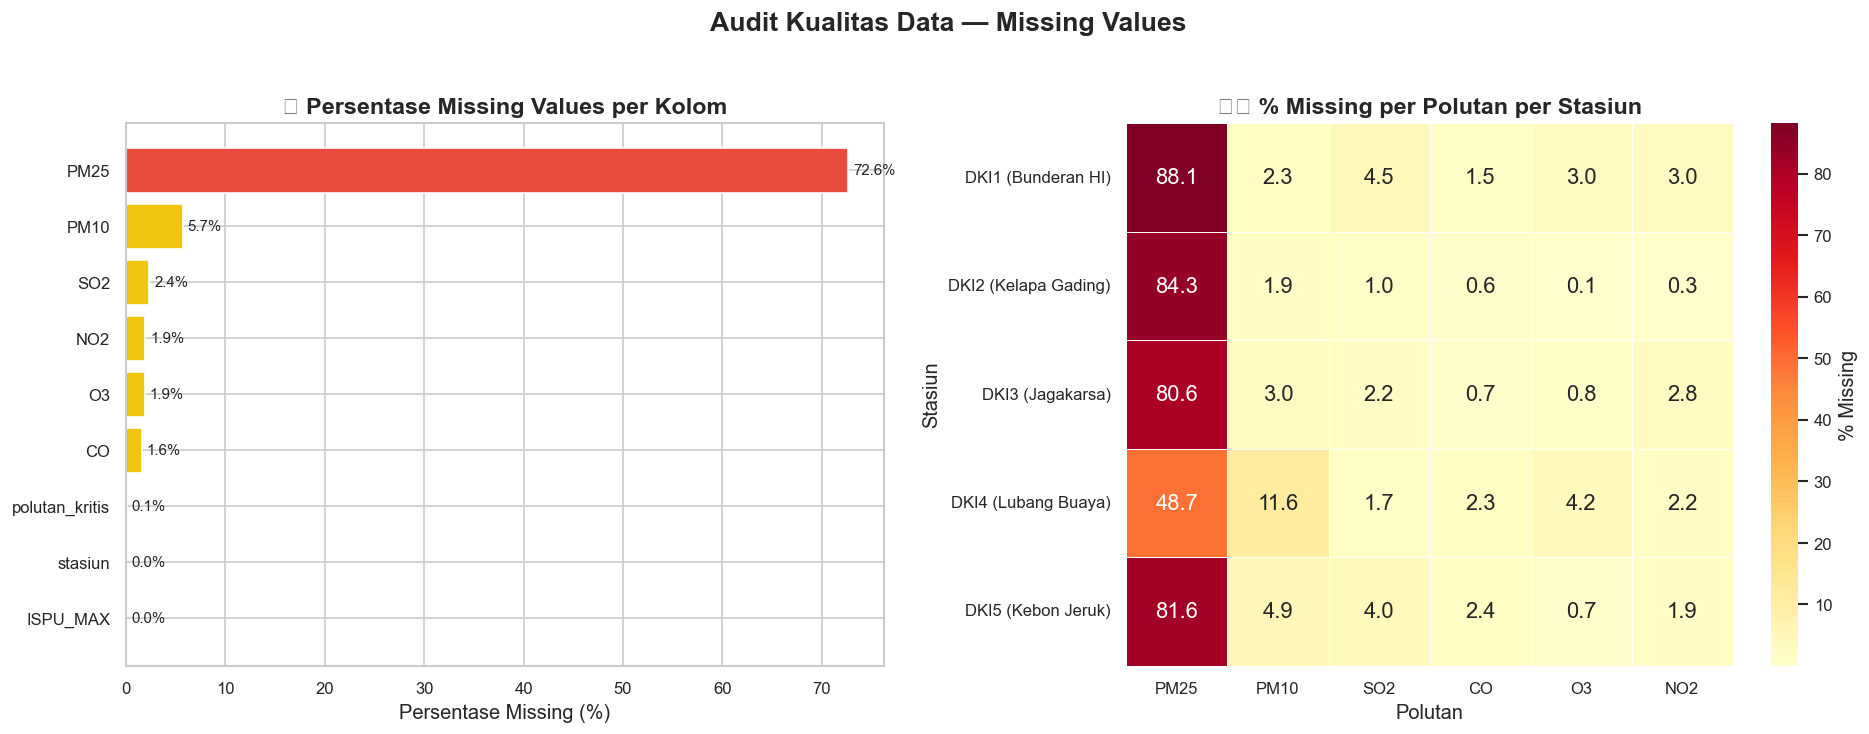


📝 Catatan: PM2.5 hampir seluruhnya kosong untuk stasiun DKI1-DKI3
   karena sensor PM2.5 baru dipasang di stasiun-stasiun tertentu lebih baru.


In [46]:
# ── Visualisasi missing value heatmap ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart missing %
miss_plot = missing[missing['% Missing'] > 0].sort_values('% Missing', ascending=True)
bars = axes[0].barh(miss_plot['Kolom'], miss_plot['% Missing'],
                    color=['#e74c3c' if x > 50 else '#e67e22' if x > 10 else '#f1c40f'
                           for x in miss_plot['% Missing']])
axes[0].set_xlabel('Persentase Missing (%)')
axes[0].set_title('📊 Persentase Missing Values per Kolom', fontweight='bold')
for bar, val in zip(bars, miss_plot['% Missing']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Heatmap missingness per stasiun
miss_station = df.groupby('stasiun')[POLUTAN_COLS].apply(lambda g: g.isnull().mean() * 100)
sns.heatmap(miss_station, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '% Missing'})
axes[1].set_title('🗺️ % Missing per Polutan per Stasiun', fontweight='bold')
axes[1].set_xlabel('Polutan')
axes[1].set_ylabel('Stasiun')

plt.suptitle('Audit Kualitas Data — Missing Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📝 Catatan: PM2.5 hampir seluruhnya kosong untuk stasiun DKI1-DKI3")
print("   karena sensor PM2.5 baru dipasang di stasiun-stasiun tertentu lebih baru.")

## 2.8 Deteksi Duplikat & Anomali

In [47]:
# ── Cek duplikat ─────────────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
n_dup_key = df.duplicated(subset=['tanggal', 'stasiun']).sum()

print("=" * 60)
print("  DETEKSI DUPLIKAT")
print("=" * 60)
print(f"  Duplikat baris penuh   : {n_dup:,} baris")
print(f"  Duplikat (tanggal+stasiun): {n_dup_key:,} baris")

print()
print("=" * 60)
print("  DETEKSI NILAI TIDAK WAJAR (negatif / nol / ekstrem)")
print("=" * 60)

for col in POLUTAN_COLS:
    neg = (df[col] < 0).sum()
    zero = (df[col] == 0).sum()
    # outlier: > Q3 + 3*IQR (extreme outlier)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    ext_out = (df[col] > Q3 + 3 * IQR).sum()
    print(f"  {col:6s}: negatif={neg}, zero={zero}, ekstrem_outlier={ext_out}")

print()
# Cek ISPU_MAX = 0
zero_ispu = (df['ISPU_MAX'] == 0).sum()
print(f"  ISPU_MAX = 0: {zero_ispu} baris (kemungkinan 'TIDAK ADA DATA')")

  DETEKSI DUPLIKAT
  Duplikat baris penuh   : 0 baris
  Duplikat (tanggal+stasiun): 0 baris

  DETEKSI NILAI TIDAK WAJAR (negatif / nol / ekstrem)
  PM25  : negatif=0, zero=0, ekstrem_outlier=3
  PM10  : negatif=0, zero=0, ekstrem_outlier=22
  SO2   : negatif=0, zero=19, ekstrem_outlier=1
  CO    : negatif=0, zero=1, ekstrem_outlier=32
  O3    : negatif=0, zero=0, ekstrem_outlier=1
  NO2   : negatif=0, zero=0, ekstrem_outlier=58

  ISPU_MAX = 0: 3 baris (kemungkinan 'TIDAK ADA DATA')


---
# 🔍 BAGIAN 3 — EXPLORATORY DATA ANALYSIS (EDA)
---

## 3.1 Distribusi Kategori ISPU (Target Variable)

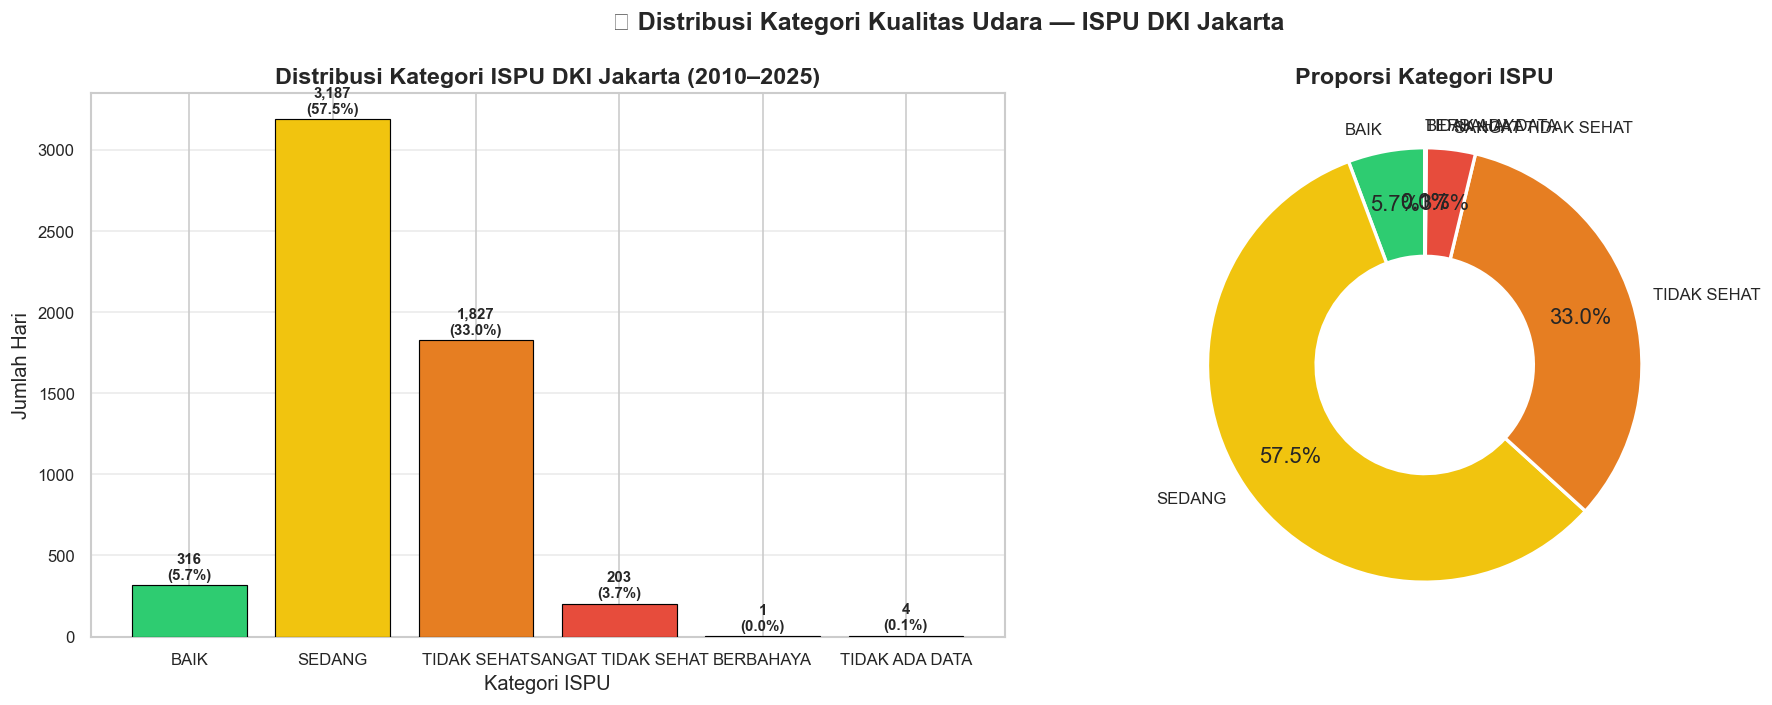


📝 INSIGHT:
   • 3,187 hari (57.5%) berada di kategori SEDANG
   • 1,827 hari (33.0%) TIDAK SEHAT — cukup mengkhawatirkan
   • Total hari dengan udara TIDAK SEHAT atau lebih buruk: 36.7%


In [48]:
# ── Distribusi kategori ISPU ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart dengan warna ISPU ---
cat_counts = df['kategori'].value_counts()
cat_ordered = [c for c in KATEGORI_ORDER if c in cat_counts.index]
counts_ordered = [cat_counts[c] for c in cat_ordered]
colors_ordered = [ISPU_COLORS[c] for c in cat_ordered]

bars = axes[0].bar(cat_ordered, counts_ordered, color=colors_ordered,
                   edgecolor='black', linewidth=0.7, zorder=3)
axes[0].set_title('Distribusi Kategori ISPU DKI Jakarta (2010–2025)', fontweight='bold')
axes[0].set_ylabel('Jumlah Hari')
axes[0].set_xlabel('Kategori ISPU')
axes[0].grid(axis='y', alpha=0.4, zorder=0)
for bar, count in zip(bars, counts_ordered):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Pie chart ---
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
axes[1].pie(counts_ordered,
            labels=cat_ordered,
            colors=colors_ordered,
            autopct='%1.1f%%',
            pctdistance=0.75,
            startangle=90,
            wedgeprops=wedge_props)
axes[1].set_title('Proporsi Kategori ISPU', fontweight='bold')

plt.suptitle('📊 Distribusi Kategori Kualitas Udara — ISPU DKI Jakarta',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 INSIGHT:")
print(f"   • {cat_counts['SEDANG']:,} hari ({cat_counts['SEDANG']/len(df)*100:.1f}%) berada di kategori SEDANG")
print(f"   • {cat_counts['TIDAK SEHAT']:,} hari ({cat_counts['TIDAK SEHAT']/len(df)*100:.1f}%) TIDAK SEHAT — cukup mengkhawatirkan")
unhealthy_pct = (cat_counts.get('TIDAK SEHAT',0) + cat_counts.get('SANGAT TIDAK SEHAT',0) + cat_counts.get('BERBAHAYA',0)) / len(df) * 100
print(f"   • Total hari dengan udara TIDAK SEHAT atau lebih buruk: {unhealthy_pct:.1f}%")

## 3.2 Tren ISPU Tahunan (2010–2025)

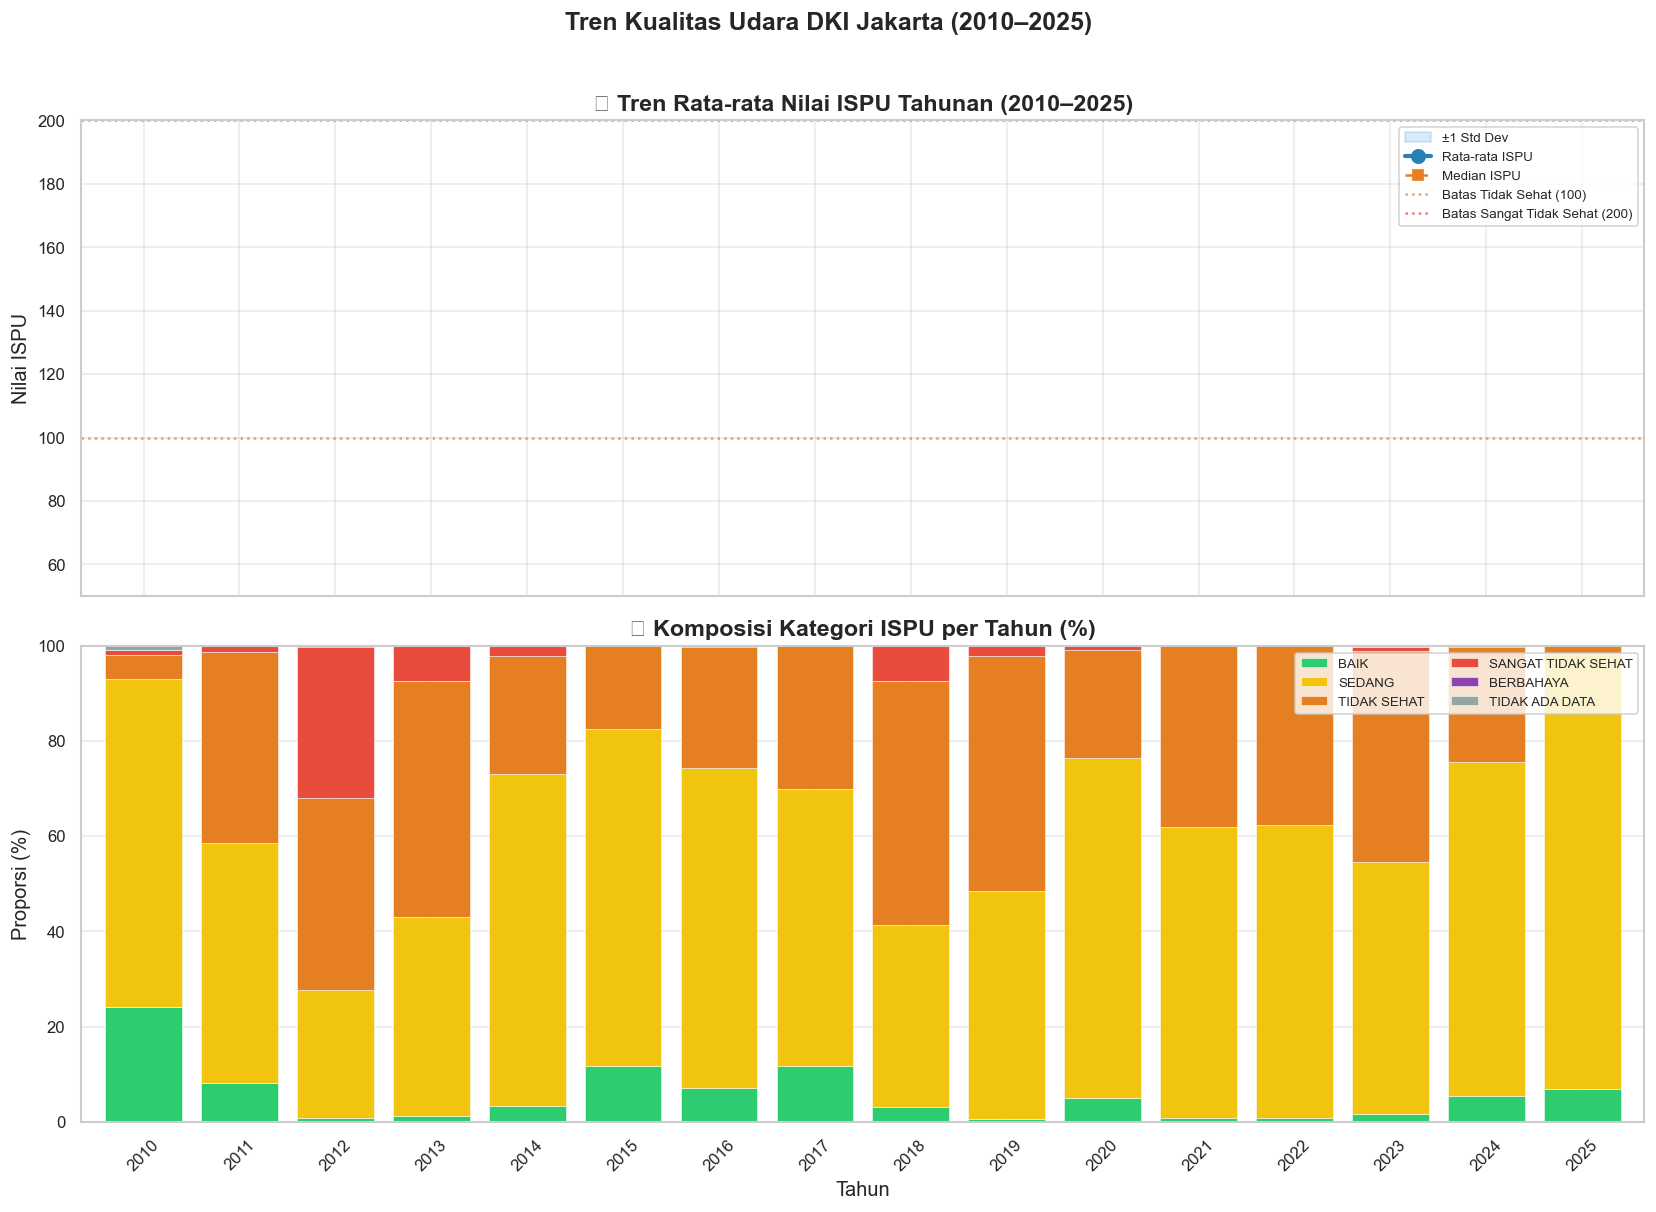


📝 INSIGHT TREN:
   • Rata-rata ISPU 2010-2012: 105.7
   • Rata-rata ISPU 2022-2024: 92.4
   • Kualitas udara cenderung: MEMBAIK (13.2 poin)
   • Efek COVID-2020: ISPU turun dari 111.4 (2019) → 87.9 (2020)


In [49]:
# ── Tren tahunan nilai ISPU ──────────────────────────────────────────────────
df_valid = df[df['ISPU_MAX'] > 0].copy()

yearly = df_valid.groupby('year')['ISPU_MAX'].agg(['mean','median','max','std']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Tren rata-rata ISPU ---
axes[0].fill_between(yearly['year'],
                     yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'],
                     alpha=0.2, color='#3498db', label='±1 Std Dev')
axes[0].plot(yearly['year'], yearly['mean'], 'o-', color='#2980b9',
             linewidth=2.5, markersize=8, label='Rata-rata ISPU', zorder=5)
axes[0].plot(yearly['year'], yearly['median'], 's--', color='#e67e22',
             linewidth=1.5, markersize=6, label='Median ISPU', zorder=5)

# Garis batas kategori
axes[0].axhline(100, color='#e67e22', linestyle=':', alpha=0.7, linewidth=1.5, label='Batas Tidak Sehat (100)')
axes[0].axhline(200, color='#e74c3c', linestyle=':', alpha=0.7, linewidth=1.5, label='Batas Sangat Tidak Sehat (200)')

# Annotate 2020 (COVID)
axes[0].annotate('COVID-19\n(2020)', xy=(2020, yearly[yearly['year']==2020]['mean'].values[0]),
                 xytext=(2018.5, 130), fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

axes[0].set_ylabel('Nilai ISPU')
axes[0].set_title('📈 Tren Rata-rata Nilai ISPU Tahunan (2010–2025)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.4)
axes[0].set_ylim(50, 200)

# --- Komposisi kategori per tahun (stacked bar) ---
cat_year = df.groupby(['year','kategori']).size().unstack(fill_value=0)
cat_year_pct = cat_year.div(cat_year.sum(axis=1), axis=0) * 100
cat_cols_plot = [c for c in KATEGORI_ORDER if c in cat_year_pct.columns]
cat_year_pct[cat_cols_plot].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[ISPU_COLORS[c] for c in cat_cols_plot],
    edgecolor='white', linewidth=0.3, width=0.8
)
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Proporsi (%)')
axes[1].set_title('📊 Komposisi Kategori ISPU per Tahun (%)', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8, ncol=2)
axes[1].grid(axis='y', alpha=0.4)
axes[1].set_xticklabels(cat_year_pct.index, rotation=45)

plt.suptitle('Tren Kualitas Udara DKI Jakarta (2010–2025)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📝 INSIGHT TREN:")
mean_first3 = yearly[yearly['year'].isin([2010,2011,2012])]['mean'].mean()
mean_last3  = yearly[yearly['year'].isin([2022,2023,2024])]['mean'].mean()
trend = "MEMBURUK" if mean_last3 > mean_first3 else "MEMBAIK"
print(f"   • Rata-rata ISPU 2010-2012: {mean_first3:.1f}")
print(f"   • Rata-rata ISPU 2022-2024: {mean_last3:.1f}")
print(f"   • Kualitas udara cenderung: {trend} ({abs(mean_last3-mean_first3):.1f} poin)")
covid_mean = yearly[yearly['year']==2020]['mean'].values[0]
precovid_mean = yearly[yearly['year']==2019]['mean'].values[0]
print(f"   • Efek COVID-2020: ISPU turun dari {precovid_mean:.1f} (2019) → {covid_mean:.1f} (2020)")

## 3.3 Pola Musiman & Bulanan

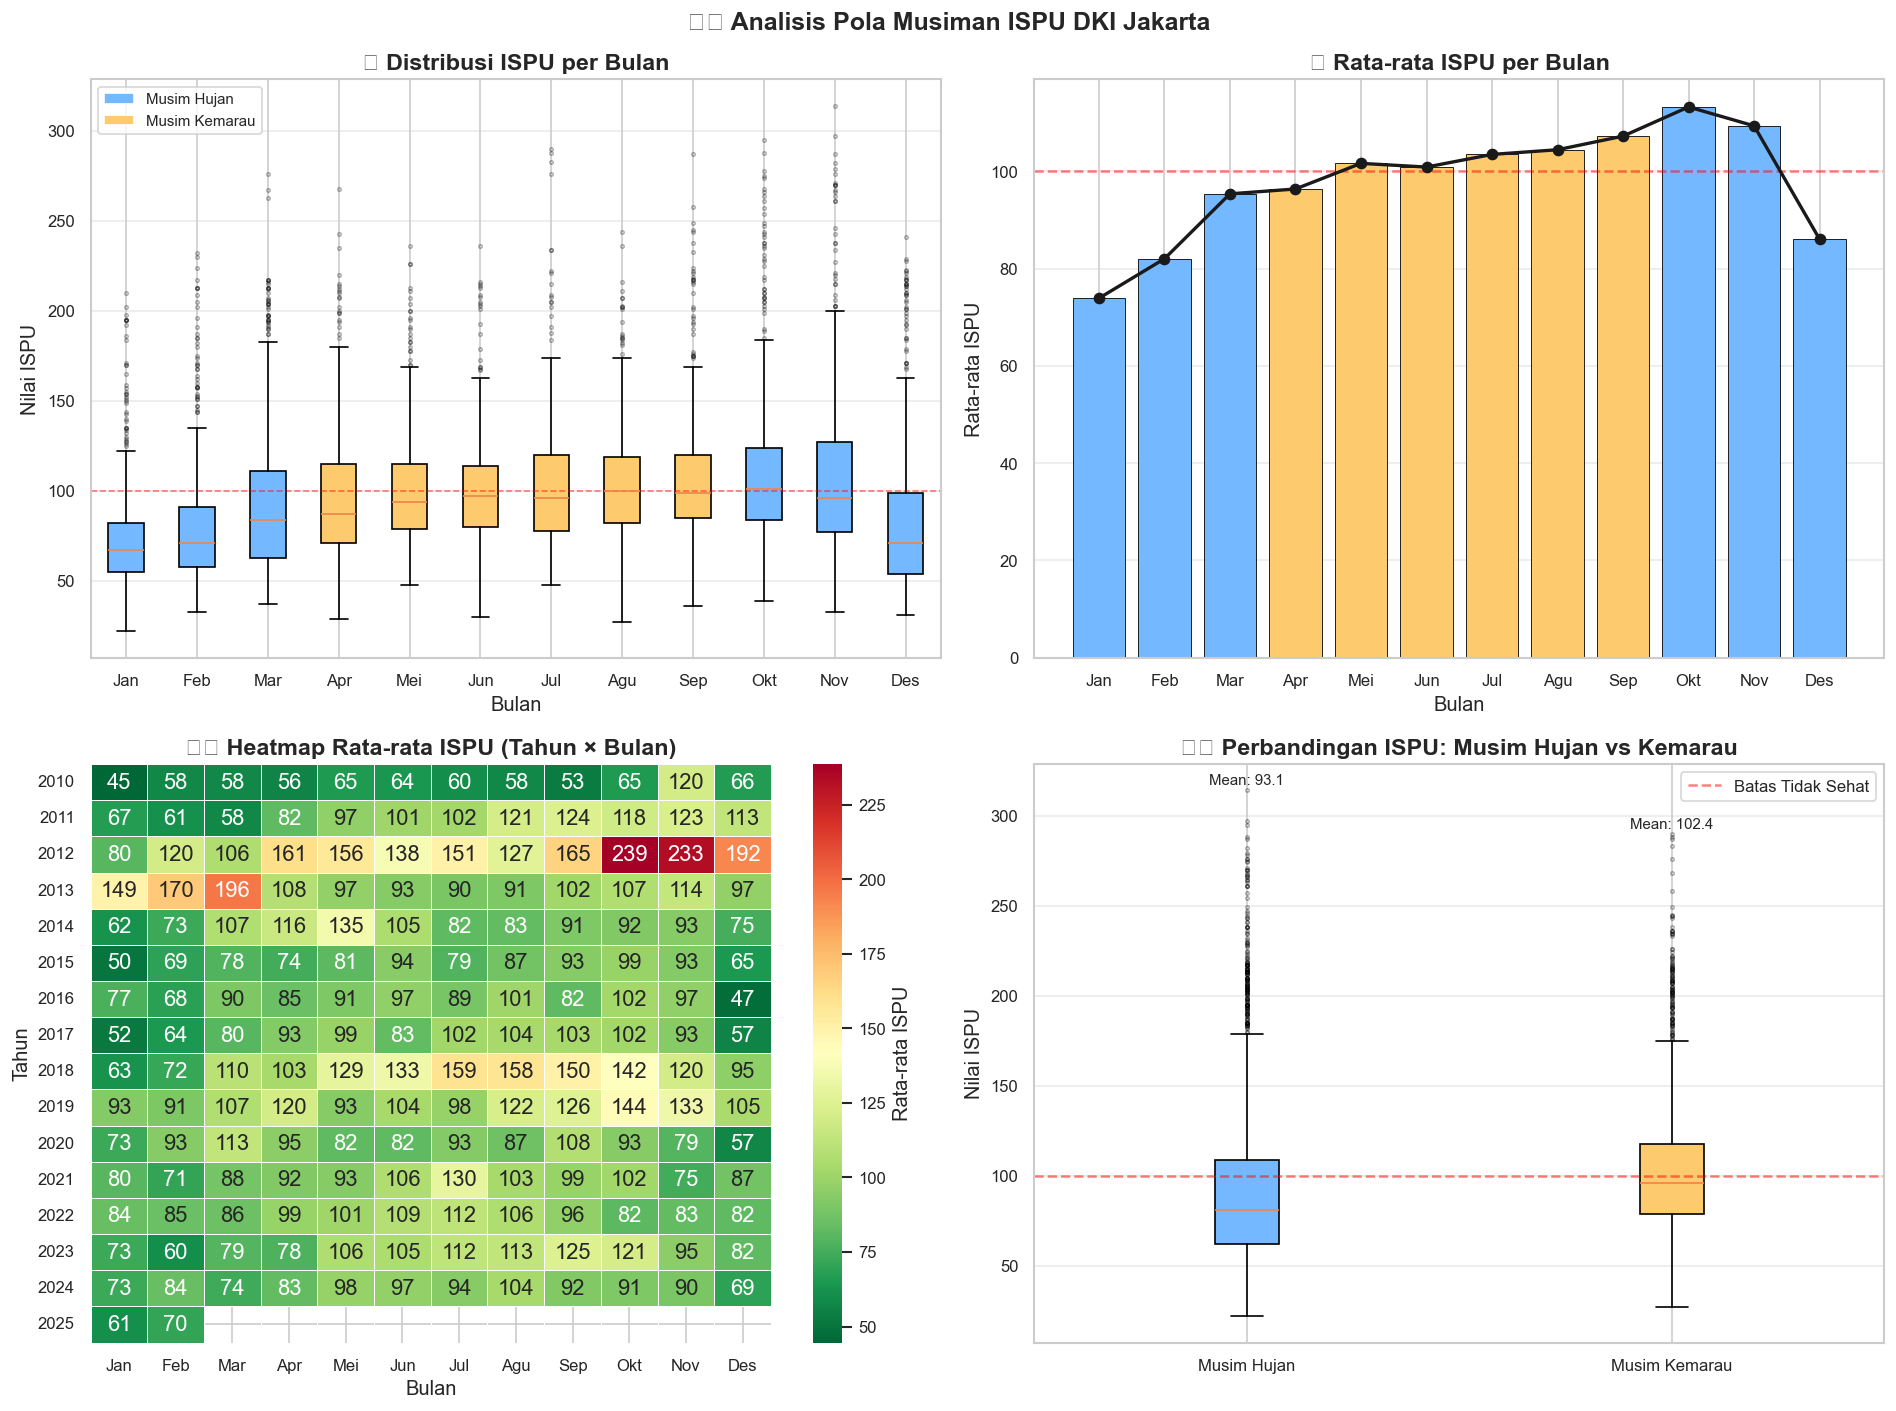


📊 UJI MANN-WHITNEY U: Musim Hujan vs Musim Kemarau
   Rata-rata Musim Hujan  : 93.08
   Rata-rata Musim Kemarau: 102.37
   Statistik U : 2916917.50
   p-value     : 0.000000
   Kesimpulan  : Perbedaan SIGNIFIKAN secara statistik ✅


In [50]:
# ── Pola musiman ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Box plot per bulan ---
month_order = list(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
monthly_data = [df_valid[df_valid['month']==m]['ISPU_MAX'].dropna().values for m in month_order]

bp = axes[0,0].boxplot(monthly_data, patch_artist=True, showfliers=True,
                        flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, month in zip(bp['boxes'], month_order):
    color = '#74b9ff' if month in [10,11,12,1,2,3] else '#fdcb6e'
    patch.set_facecolor(color)
axes[0,0].set_xticklabels(month_labels)
axes[0,0].set_xlabel('Bulan')
axes[0,0].set_ylabel('Nilai ISPU')
axes[0,0].set_title('📦 Distribusi ISPU per Bulan', fontweight='bold')
axes[0,0].axhline(100, color='red', linestyle='--', alpha=0.5, linewidth=1)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#74b9ff', label='Musim Hujan'),
              Patch(facecolor='#fdcb6e', label='Musim Kemarau')]
axes[0,0].legend(handles=legend_els, fontsize=9)
axes[0,0].grid(axis='y', alpha=0.4)

# --- Rata-rata ISPU per bulan (line) ---
monthly_avg = df_valid.groupby('month')['ISPU_MAX'].mean()
axes[0,1].bar(month_labels, monthly_avg.values,
              color=['#74b9ff' if m in [10,11,12,1,2,3] else '#fdcb6e' for m in month_order],
              edgecolor='black', linewidth=0.5)
axes[0,1].plot(range(12), monthly_avg.values, 'ko-', markersize=6, linewidth=2, zorder=5)
axes[0,1].set_xlabel('Bulan')
axes[0,1].set_ylabel('Rata-rata ISPU')
axes[0,1].set_title('📉 Rata-rata ISPU per Bulan', fontweight='bold')
axes[0,1].axhline(100, color='red', linestyle='--', alpha=0.5)
axes[0,1].grid(axis='y', alpha=0.4)
axes[0,1].set_xticks(range(12))
axes[0,1].set_xticklabels(month_labels)

# --- Heatmap bulan × tahun ---
pivot_monthly = df_valid.pivot_table(values='ISPU_MAX', index='year', columns='month', aggfunc='mean')
pivot_monthly.columns = month_labels
sns.heatmap(pivot_monthly, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.3, ax=axes[1,0], cbar_kws={'label': 'Rata-rata ISPU'})
axes[1,0].set_title('🗓️ Heatmap Rata-rata ISPU (Tahun × Bulan)', fontweight='bold')
axes[1,0].set_xlabel('Bulan')
axes[1,0].set_ylabel('Tahun')

# --- Musim Hujan vs Kemarau ---
musim_agg = df_valid.groupby('musim')['ISPU_MAX'].describe()
musim_groups = [df_valid[df_valid['musim']==m]['ISPU_MAX'].dropna() for m in ['Musim Hujan','Musim Kemarau']]
bp2 = axes[1,1].boxplot(musim_groups, patch_artist=True,
                         labels=['Musim Hujan', 'Musim Kemarau'],
                         flierprops=dict(marker='o', markersize=2, alpha=0.3))
bp2['boxes'][0].set_facecolor('#74b9ff')
bp2['boxes'][1].set_facecolor('#fdcb6e')
axes[1,1].set_ylabel('Nilai ISPU')
axes[1,1].set_title('🌧️ Perbandingan ISPU: Musim Hujan vs Kemarau', fontweight='bold')
axes[1,1].axhline(100, color='red', linestyle='--', alpha=0.5, label='Batas Tidak Sehat')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.4)
# Tambah stat
for i, (group, label) in enumerate(zip(musim_groups, ['Musim Hujan','Musim Kemarau']), 1):
    axes[1,1].text(i, group.max()+3, f'Mean: {group.mean():.1f}', ha='center', fontsize=9)

plt.suptitle('🌦️ Analisis Pola Musiman ISPU DKI Jakarta',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Uji statistik musim ───────────────────────────────────────────────────────
stat, p_val = stats.mannwhitneyu(musim_groups[0], musim_groups[1], alternative='two-sided')
print("\n📊 UJI MANN-WHITNEY U: Musim Hujan vs Musim Kemarau")
print(f"   Rata-rata Musim Hujan  : {musim_groups[0].mean():.2f}")
print(f"   Rata-rata Musim Kemarau: {musim_groups[1].mean():.2f}")
print(f"   Statistik U : {stat:.2f}")
print(f"   p-value     : {p_val:.6f}")
print(f"   Kesimpulan  : {'Perbedaan SIGNIFIKAN secara statistik ✅' if p_val < 0.05 else 'Tidak signifikan'}")

## 3.4 Analisis per Stasiun

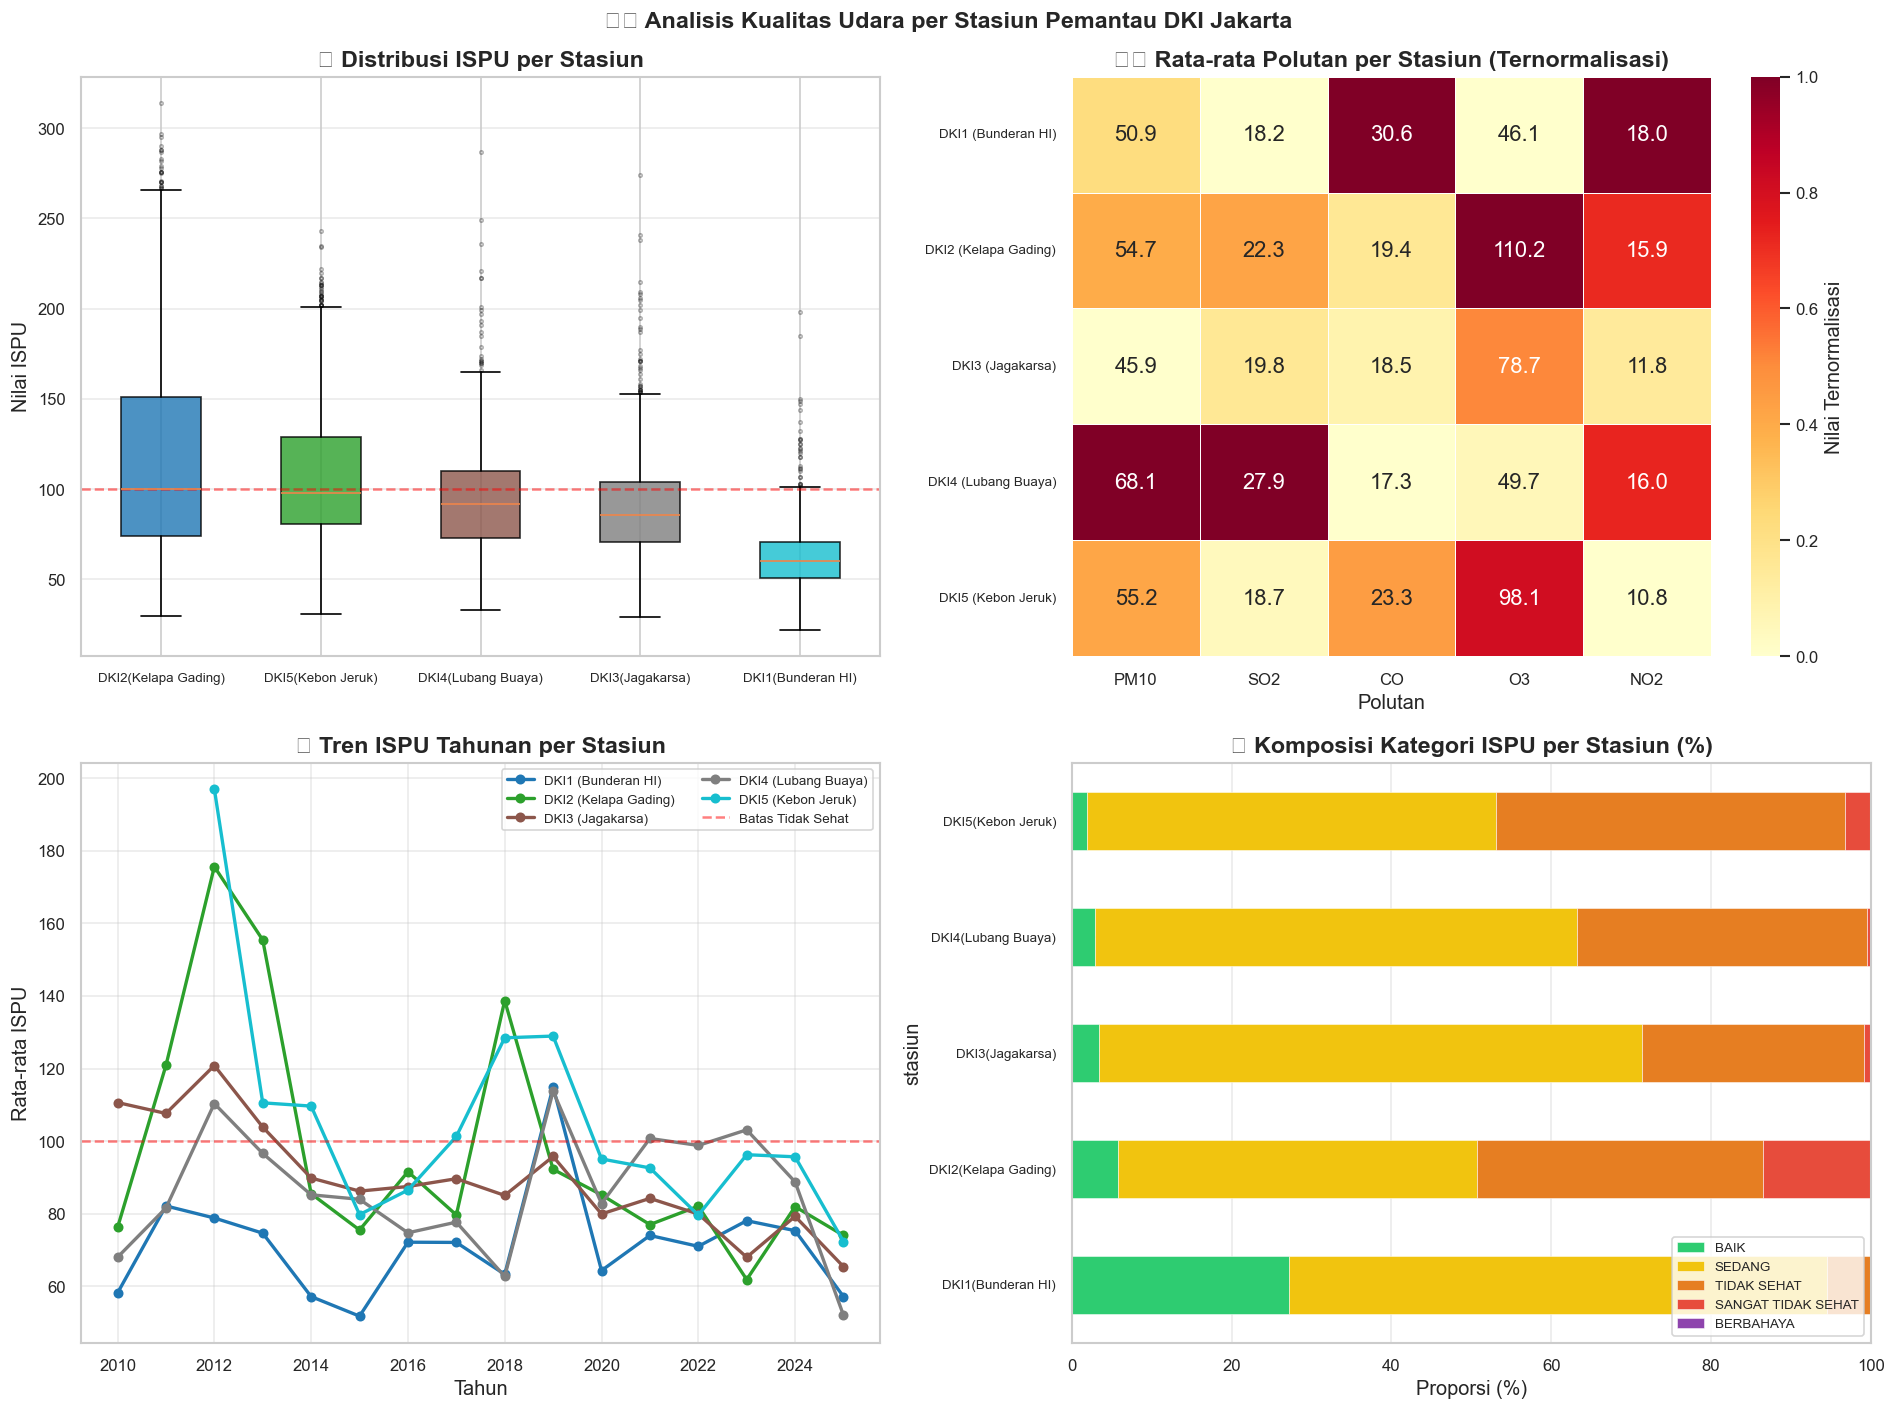


📝 INSIGHT STASIUN:
   • Stasiun TERBAIK  (ISPU terkecil): DKI1 (Bunderan HI)
   • Stasiun TERBURUK (ISPU terbesar): DKI2 (Kelapa Gading)


In [53]:
# ── Perbandingan antar stasiun ───────────────────────────────────────────────
df_st = df_valid[df_valid['stasiun'].notna()].copy()
stations = df_st['stasiun'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Box plot ISPU per stasiun ---
st_order = df_st.groupby('stasiun')['ISPU_MAX'].mean().sort_values(ascending=False).index
st_data  = [df_st[df_st['stasiun']==s]['ISPU_MAX'].dropna().values for s in st_order]
st_labels = [s.replace(' (','(') for s in st_order]

bp3 = axes[0,0].boxplot(st_data, patch_artist=True,
                          flierprops=dict(marker='o', markersize=2, alpha=0.3),
                          labels=st_labels)
cmap_st = plt.cm.get_cmap('tab10', len(stations))
for i, patch in enumerate(bp3['boxes']):
    patch.set_facecolor(cmap_st(i))
    patch.set_alpha(0.8)
axes[0,0].set_ylabel('Nilai ISPU')
axes[0,0].set_title('📦 Distribusi ISPU per Stasiun', fontweight='bold')
axes[0,0].axhline(100, color='red', linestyle='--', alpha=0.5)
axes[0,0].tick_params(axis='x', labelsize=8)
axes[0,0].grid(axis='y', alpha=0.4)

# --- Rata-rata polutan per stasiun (heatmap) ---
st_pol = df_st.groupby('stasiun')[['PM10','SO2','CO','O3','NO2']].mean()
# Normalisasi per polutan
st_pol_norm = (st_pol - st_pol.min()) / (st_pol.max() - st_pol.min())
sns.heatmap(st_pol_norm, annot=st_pol.round(1), fmt='.1f',
            cmap='YlOrRd', ax=axes[0,1], linewidths=0.5,
            cbar_kws={'label': 'Nilai Ternormalisasi'})
axes[0,1].set_title('🌡️ Rata-rata Polutan per Stasiun (Ternormalisasi)', fontweight='bold')
axes[0,1].set_xlabel('Polutan')
axes[0,1].set_ylabel('')
axes[0,1].set_yticklabels(axes[0,1].get_yticklabels(), rotation=0, fontsize=8)

# --- Tren tahunan per stasiun ---
st_yr = df_st.groupby(['year','stasiun'])['ISPU_MAX'].mean().reset_index()
for i, station in enumerate(stations):
    subset = st_yr[st_yr['stasiun']==station]
    axes[1,0].plot(subset['year'], subset['ISPU_MAX'], 'o-',
                   label=station, linewidth=2, markersize=5, color=cmap_st(i))
axes[1,0].axhline(100, color='red', linestyle='--', alpha=0.5, label='Batas Tidak Sehat')
axes[1,0].set_xlabel('Tahun')
axes[1,0].set_ylabel('Rata-rata ISPU')
axes[1,0].set_title('📈 Tren ISPU Tahunan per Stasiun', fontweight='bold')
axes[1,0].legend(fontsize=8, ncol=2)
axes[1,0].grid(alpha=0.4)

# --- Proporsi kategori per stasiun ---
st_cat = df_st.groupby(['stasiun','kategori']).size().unstack(fill_value=0)
st_cat_pct = st_cat.div(st_cat.sum(axis=1), axis=0) * 100
cat_plot_cols = [c for c in KATEGORI_ORDER if c in st_cat_pct.columns]
st_cat_pct[cat_plot_cols].plot(
    kind='barh', stacked=True, ax=axes[1,1],
    color=[ISPU_COLORS[c] for c in cat_plot_cols],
    edgecolor='white', linewidth=0.3
)
axes[1,1].set_xlabel('Proporsi (%)')
axes[1,1].set_title('📊 Komposisi Kategori ISPU per Stasiun (%)', fontweight='bold')
axes[1,1].legend(loc='lower right', fontsize=8)
axes[1,1].set_yticklabels([s.replace(' (','(') for s in st_cat_pct.index], fontsize=8)
axes[1,1].grid(axis='x', alpha=0.4)

plt.suptitle('🏙️ Analisis Kualitas Udara per Stasiun Pemantau DKI Jakarta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 INSIGHT STASIUN:")
best_st   = df_st.groupby('stasiun')['ISPU_MAX'].mean().idxmin()
worst_st  = df_st.groupby('stasiun')['ISPU_MAX'].mean().idxmax()
print(f"   • Stasiun TERBAIK  (ISPU terkecil): {best_st}")
print(f"   • Stasiun TERBURUK (ISPU terbesar): {worst_st}")

## 3.5 Analisis Polutan Kritis

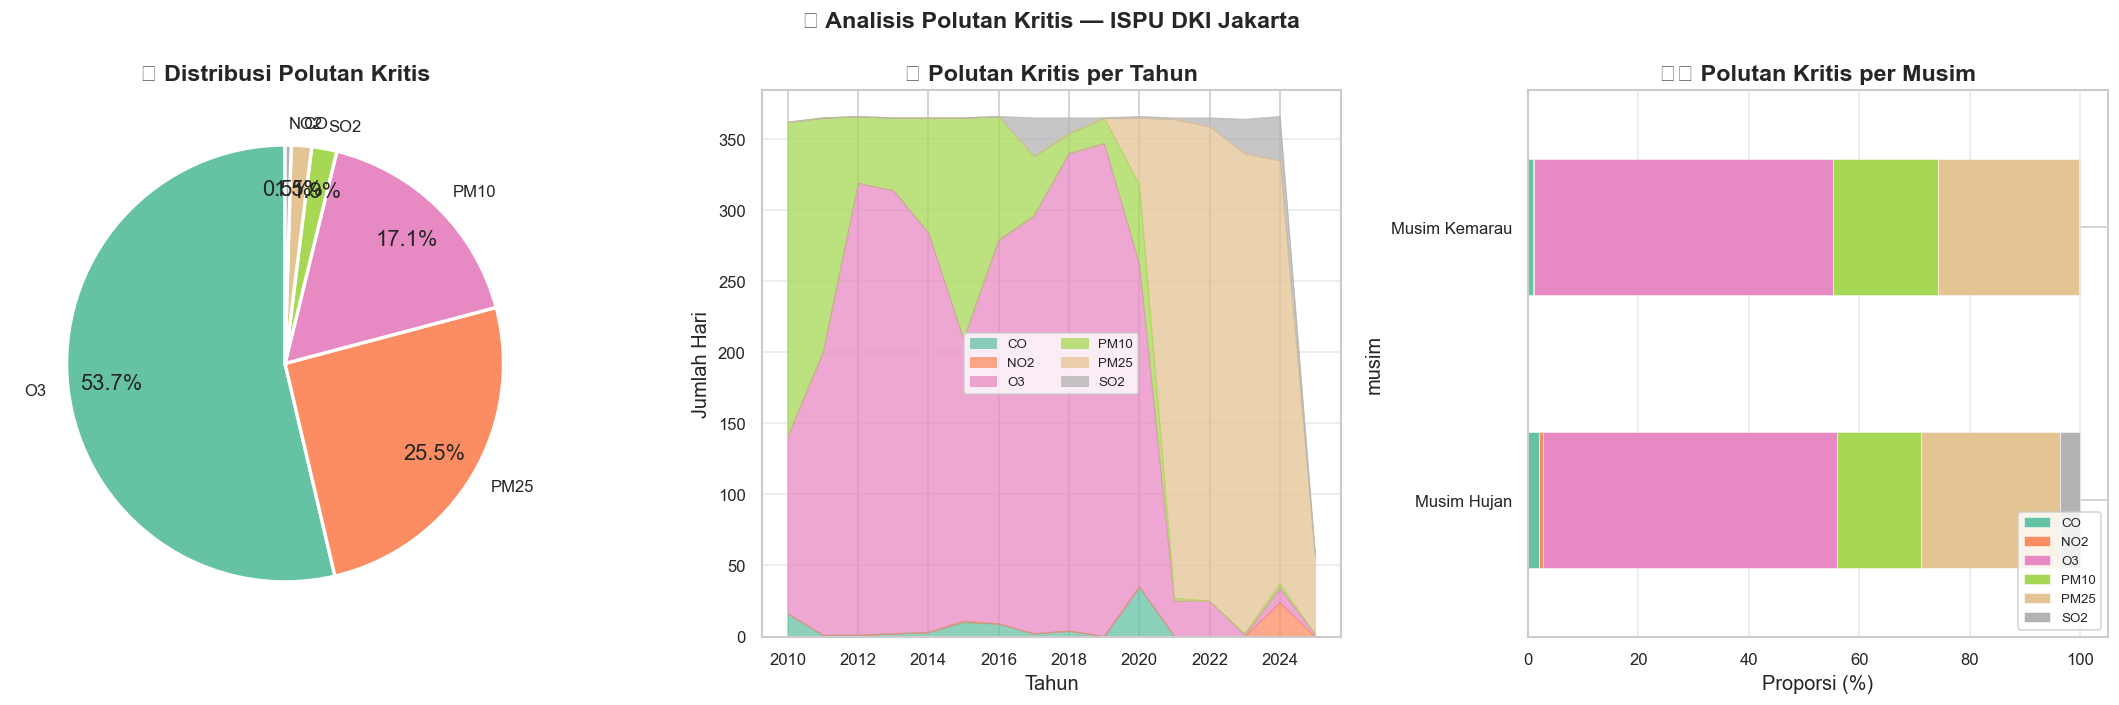


📝 INSIGHT POLUTAN KRITIS:
   • O₃ (Ozon) mendominasi sebagai polutan kritis: 2,970 hari (53.7%)
   • PM2.5 menjadi kritis sebanyak: 1,409 hari (25.5%)
   • PM10 menjadi kritis sebanyak: 944 hari (17.1%)
   • Ozon troposferik terbentuk dari reaksi fotokimia → intensitas matahari tinggi
   • PM2.5 berbahaya karena menembus masuk ke paru-paru


In [54]:
# ── Polutan kritis dominan ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Frekuensi polutan kritis ---
pk = df['polutan_kritis'].value_counts()
cmap_pk = plt.cm.get_cmap('Set2', len(pk))
wedges, texts, autotexts = axes[0].pie(
    pk.values, labels=pk.index,
    autopct='%1.1f%%', startangle=90,
    colors=[cmap_pk(i) for i in range(len(pk))],
    pctdistance=0.8,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('🏆 Distribusi Polutan Kritis', fontweight='bold')

# --- Polutan kritis per tahun (stacked area) ---
pk_yr = df.groupby(['year','polutan_kritis']).size().unstack(fill_value=0)
pk_cols = pk_yr.columns.tolist()
pk_yr[pk_cols].plot(kind='area', stacked=True, ax=axes[1],
                     alpha=0.75, colormap='Set2', linewidth=0.5)
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah Hari')
axes[1].set_title('📅 Polutan Kritis per Tahun', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(axis='y', alpha=0.4)

# --- Polutan kritis per musim ---
pk_musim = df.groupby(['musim','polutan_kritis']).size().unstack(fill_value=0)
pk_musim_pct = pk_musim.div(pk_musim.sum(axis=1), axis=0) * 100
pk_musim_pct.plot(kind='barh', stacked=True, ax=axes[2],
                   colormap='Set2', edgecolor='white', linewidth=0.3)
axes[2].set_xlabel('Proporsi (%)')
axes[2].set_title('🌦️ Polutan Kritis per Musim', fontweight='bold')
axes[2].legend(fontsize=8, loc='lower right')
axes[2].grid(axis='x', alpha=0.4)

plt.suptitle('🧪 Analisis Polutan Kritis — ISPU DKI Jakarta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 INSIGHT POLUTAN KRITIS:")
print(f"   • O₃ (Ozon) mendominasi sebagai polutan kritis: {pk.get('O3',0):,} hari ({pk.get('O3',0)/pk.sum()*100:.1f}%)")
print(f"   • PM2.5 menjadi kritis sebanyak: {pk.get('PM25',0):,} hari ({pk.get('PM25',0)/pk.sum()*100:.1f}%)")
print(f"   • PM10 menjadi kritis sebanyak: {pk.get('PM10',0):,} hari ({pk.get('PM10',0)/pk.sum()*100:.1f}%)")
print("   • Ozon troposferik terbentuk dari reaksi fotokimia → intensitas matahari tinggi")
print("   • PM2.5 berbahaya karena menembus masuk ke paru-paru")

## 3.6 Distribusi Nilai Polutan & Deteksi Outlier

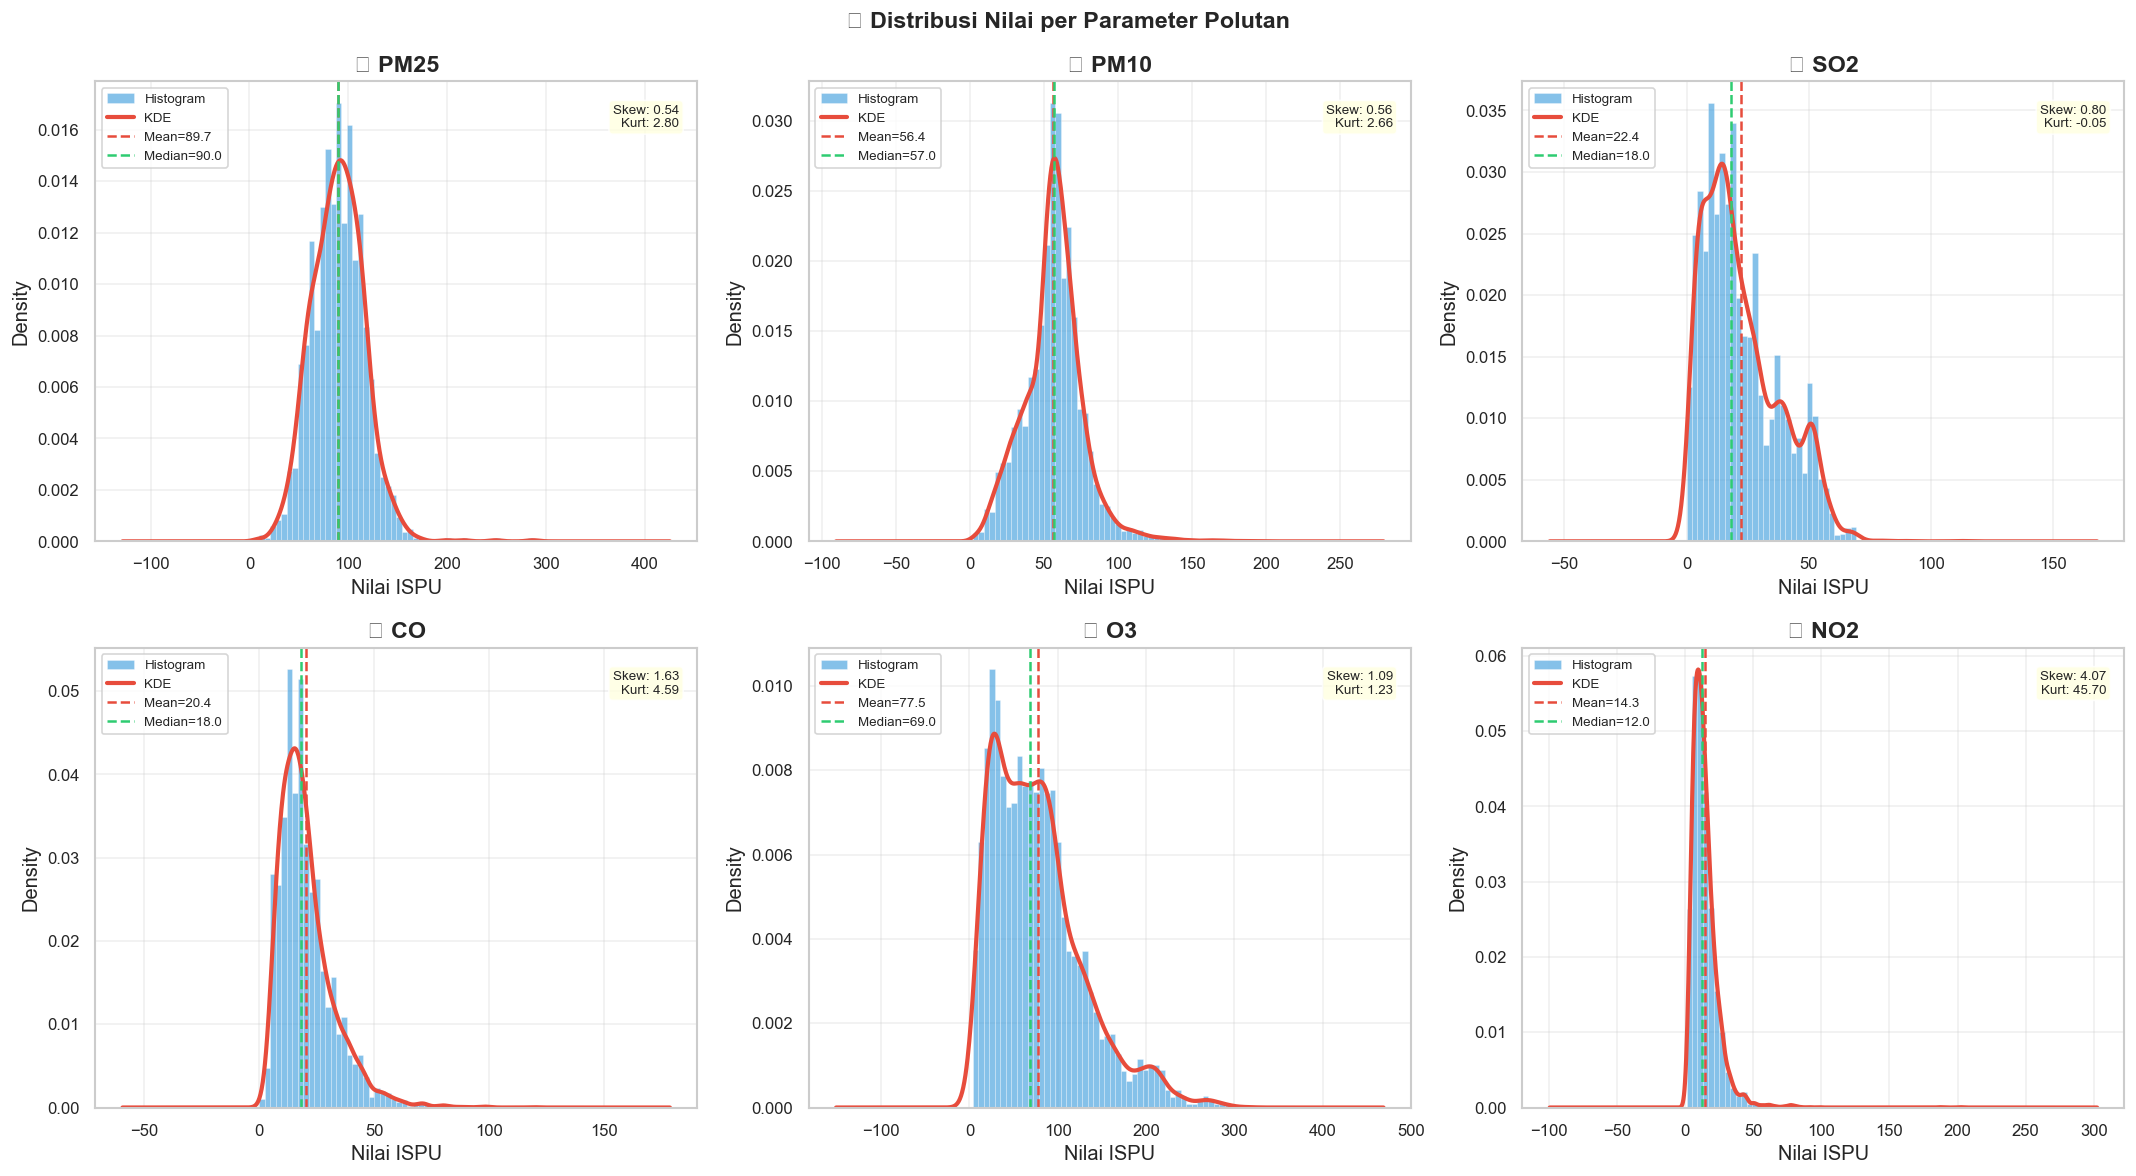


📝 RINGKASAN DISTRIBUSI:
   PM25  : skewness=0.54 → Right-skewed (ekor kanan panjang)
   PM10  : skewness=0.56 → Right-skewed (ekor kanan panjang)
   SO2   : skewness=0.80 → Right-skewed (ekor kanan panjang)
   CO    : skewness=1.63 → Right-skewed (ekor kanan panjang)
   O3    : skewness=1.09 → Right-skewed (ekor kanan panjang)
   NO2   : skewness=4.07 → Right-skewed (ekor kanan panjang)


In [55]:
# ── Distribusi tiap polutan ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(POLUTAN_COLS):
    data = df[col].dropna()
    ax = axes[i]

    # Histogram + KDE
    ax.hist(data, bins=50, density=True, color='#3498db', alpha=0.6,
            edgecolor='white', linewidth=0.3, label='Histogram')
    data.plot.kde(ax=ax, color='#e74c3c', linewidth=2.5, label='KDE')

    # Statistik dasar
    mean_val = data.mean()
    med_val  = data.median()
    ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5,
               label=f'Mean={mean_val:.1f}')
    ax.axvline(med_val, color='#2ecc71', linestyle='--', linewidth=1.5,
               label=f'Median={med_val:.1f}')

    ax.set_title(f'📊 {col}', fontweight='bold')
    ax.set_xlabel('Nilai ISPU')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Skewness & Kurtosis
    skew = data.skew()
    kurt = data.kurtosis()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('📈 Distribusi Nilai per Parameter Polutan',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 RINGKASAN DISTRIBUSI:")
for col in POLUTAN_COLS:
    data = df[col].dropna()
    skew = data.skew()
    print(f"   {col:6s}: skewness={skew:.2f} → {'Right-skewed (ekor kanan panjang)' if skew > 0.5 else 'Approximately Normal' if abs(skew) < 0.5 else 'Left-skewed'}")

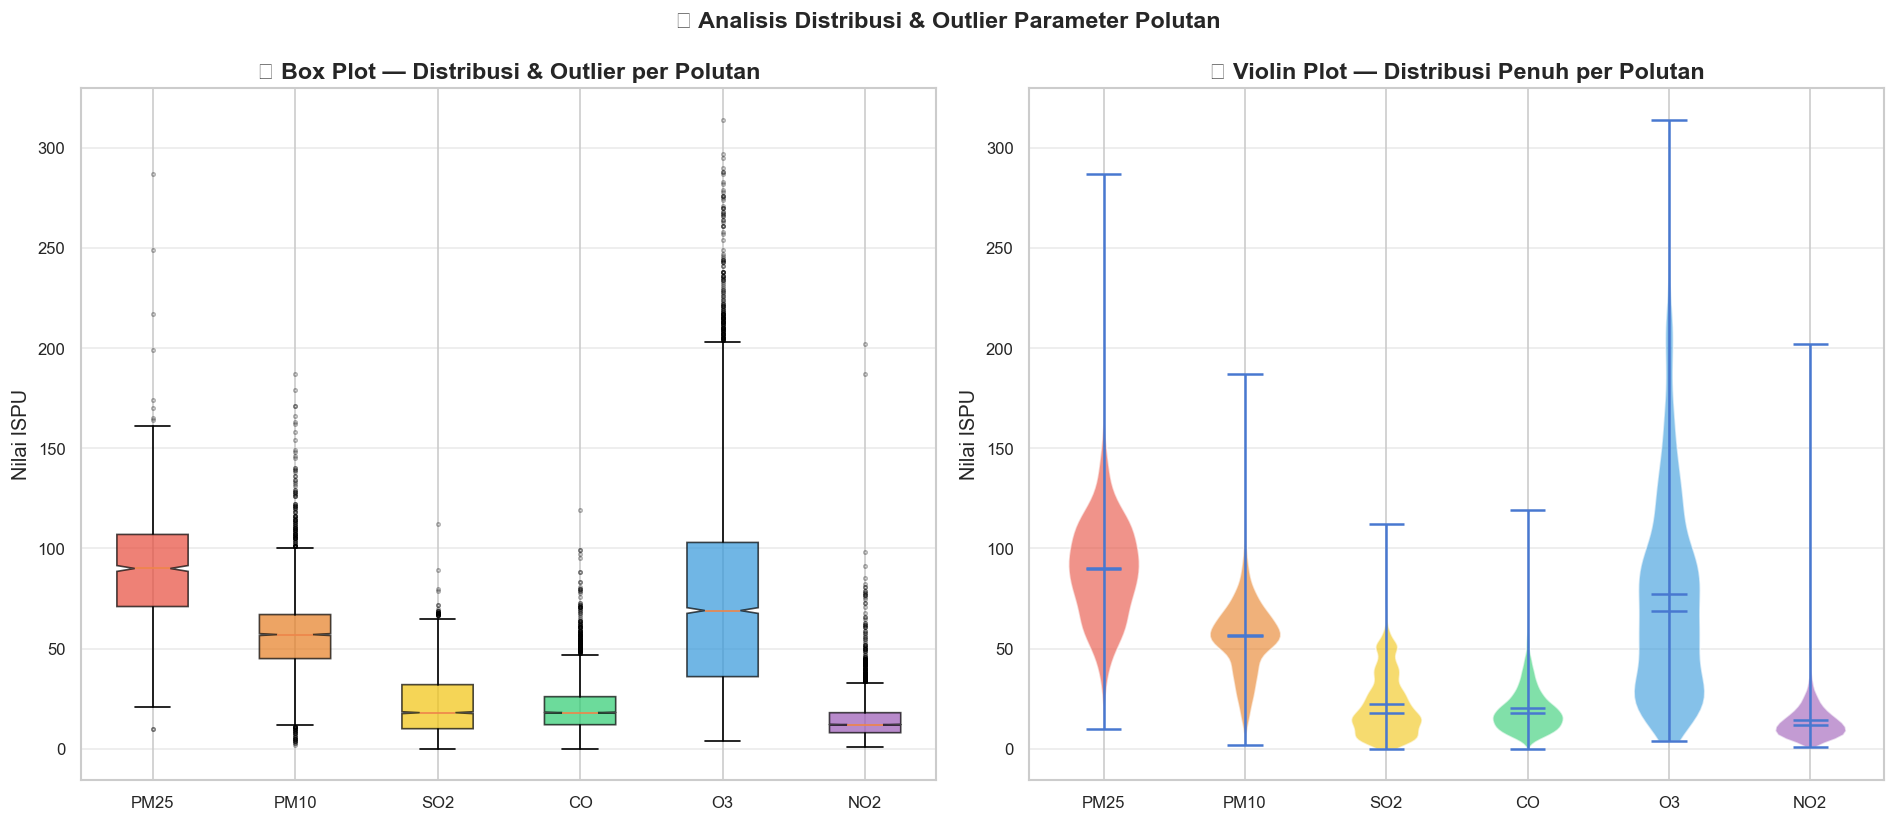


📊 RINGKASAN OUTLIER (Metode IQR):
Polutan        Q1       Q3      IQR  Batas Bawah Batas Atas  N Outlier  % Outlier
-------------------------------------------------------------------------------------
PM25         71.0    107.0     36.0         17.0      161.0         10      0.66%
PM10         45.0     67.0     22.0         12.0      100.0        156      2.99%
SO2          10.0     32.0     22.0        -23.0       65.0         29      0.54%
CO           12.0     26.0     14.0         -9.0       47.0        166      3.05%
O3           36.0    103.0     67.0        -64.5      203.5        175      3.22%
NO2           8.0     18.0     10.0         -7.0       33.0        198      3.65%


In [56]:
# ── Box plot outlier per polutan ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Box plot semua polutan ---
df_melt = df[POLUTAN_COLS].melt(var_name='Polutan', value_name='Nilai ISPU')
df_melt.dropna(inplace=True)

bp4 = axes[0].boxplot(
    [df[col].dropna().values for col in POLUTAN_COLS],
    patch_artist=True,
    labels=POLUTAN_COLS,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='red'),
    notch=True
)
colors_pol = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
for patch, color in zip(bp4['boxes'], colors_pol):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Nilai ISPU')
axes[0].set_title('📦 Box Plot — Distribusi & Outlier per Polutan', fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# --- Violin plot ---
ax_vio = axes[1]
parts = ax_vio.violinplot(
    [df[col].dropna().values for col in POLUTAN_COLS],
    positions=range(1, len(POLUTAN_COLS)+1),
    showmeans=True, showmedians=True
)
for pc, color in zip(parts['bodies'], colors_pol):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax_vio.set_xticks(range(1, len(POLUTAN_COLS)+1))
ax_vio.set_xticklabels(POLUTAN_COLS)
ax_vio.set_ylabel('Nilai ISPU')
ax_vio.set_title('🎻 Violin Plot — Distribusi Penuh per Polutan', fontweight='bold')
ax_vio.grid(axis='y', alpha=0.4)

plt.suptitle('🔍 Analisis Distribusi & Outlier Parameter Polutan',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Tabel outlier IQR ─────────────────────────────────────────────────────────
print("\n📊 RINGKASAN OUTLIER (Metode IQR):")
print(f"{'Polutan':8s} {'Q1':>8s} {'Q3':>8s} {'IQR':>8s} {'Batas Bawah':>12s} {'Batas Atas':>10s} {'N Outlier':>10s} {'% Outlier':>10s}")
print("-" * 85)
for col in POLUTAN_COLS:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((data < lb) | (data > ub)).sum()
    pct   = n_out / len(data) * 100
    print(f"{col:8s} {Q1:8.1f} {Q3:8.1f} {IQR:8.1f} {lb:12.1f} {ub:10.1f} {n_out:10d} {pct:9.2f}%")

## 3.7 Analisis Korelasi Antar Polutan

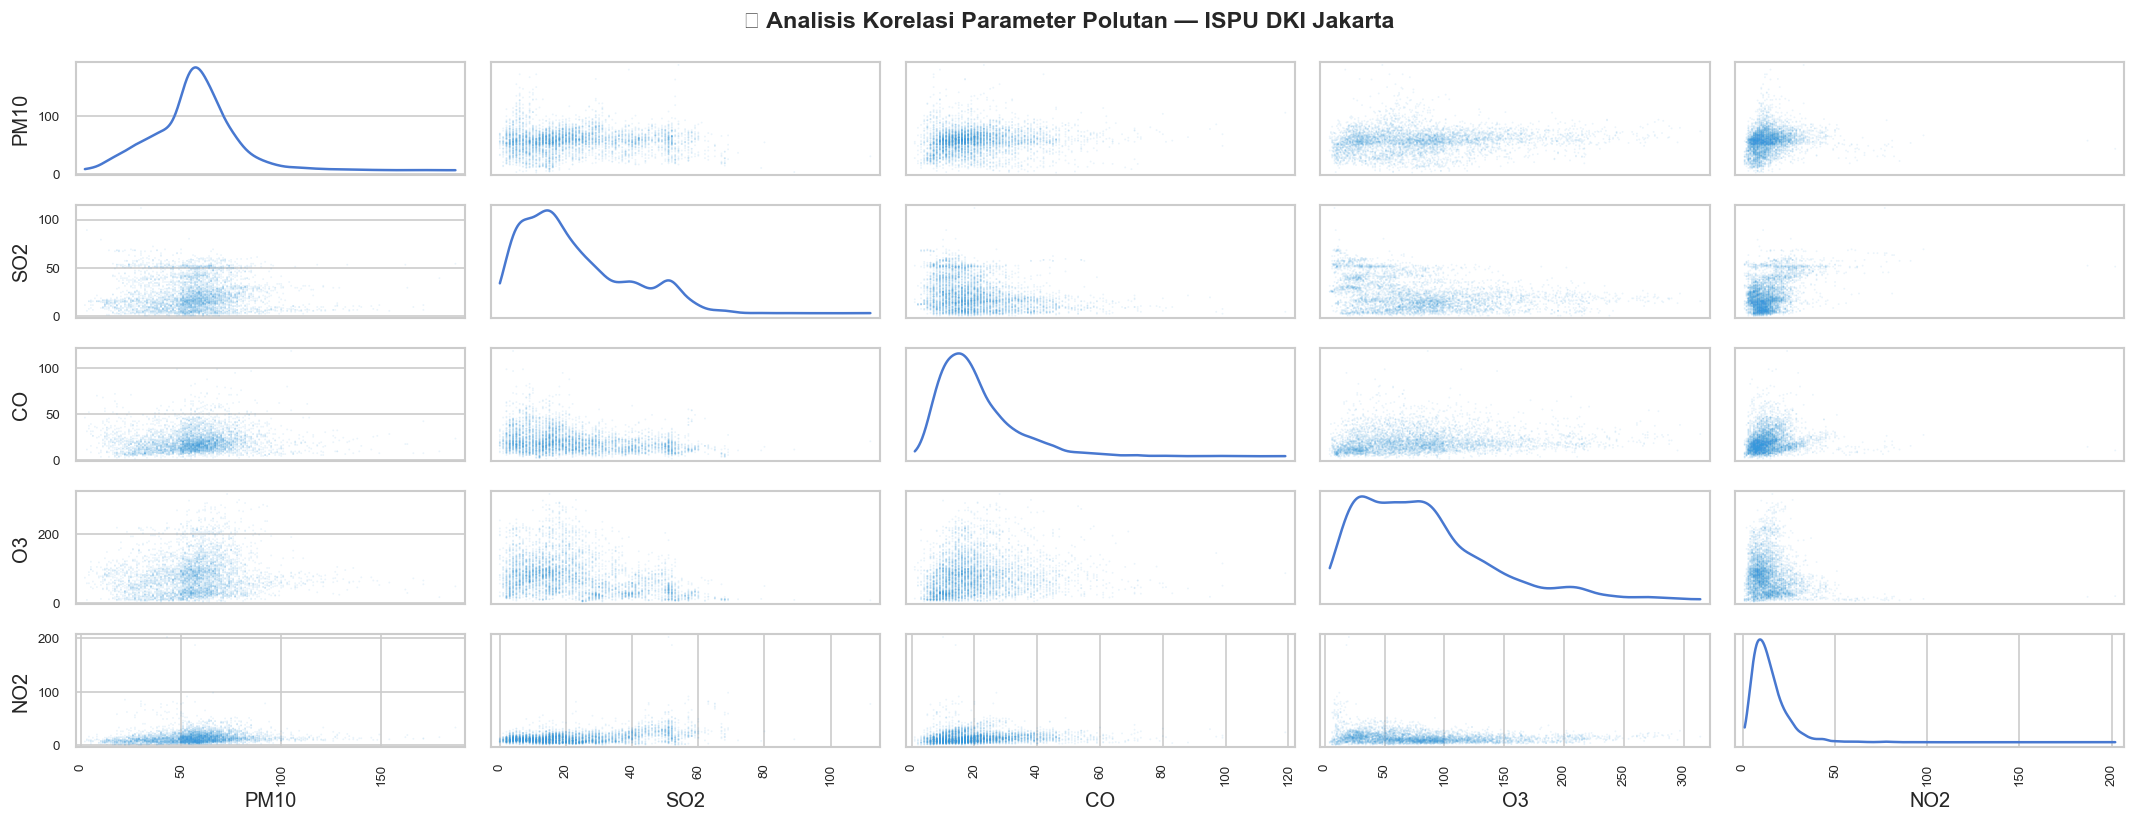


📝 INSIGHT KORELASI:
   PM25   ↔ ISPU_MAX: r=0.939 → Korelasi KUAT (+)
   O3     ↔ ISPU_MAX: r=0.819 → Korelasi KUAT (+)
   PM10   ↔ ISPU_MAX: r=0.334 → Korelasi SEDANG (+)
   NO2    ↔ ISPU_MAX: r=0.058 → Korelasi LEMAH (+)
   CO     ↔ ISPU_MAX: r=0.052 → Korelasi LEMAH (+)
   SO2    ↔ ISPU_MAX: r=-0.059 → Korelasi LEMAH (-)


In [57]:
# ── Matriks korelasi ─────────────────────────────────────────────────────────
corr_cols = POLUTAN_COLS + ['ISPU_MAX']
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Heatmap korelasi ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'},
            cbar_kws={'label': 'Korelasi Pearson'})
axes[0].set_title('🔥 Matriks Korelasi Antar Polutan & ISPU', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# --- Scatter matrix (pairplot) untuk polutan utama ---
pol_subset = df[['PM10','SO2','CO','O3','NO2']].dropna()
from pandas.plotting import scatter_matrix
sm = scatter_matrix(pol_subset, ax=axes[1], alpha=0.1, figsize=(8,8),
                    diagonal='kde', color='#3498db', s=5)
axes[1].set_title('📊 Scatter Matrix Polutan', fontweight='bold')

plt.suptitle('🔗 Analisis Korelasi Parameter Polutan — ISPU DKI Jakarta',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📝 INSIGHT KORELASI:")
corr_ispu = corr_matrix['ISPU_MAX'].drop('ISPU_MAX').sort_values(ascending=False)
for pol, val in corr_ispu.items():
    kuat = 'KUAT' if abs(val) > 0.6 else 'SEDANG' if abs(val) > 0.3 else 'LEMAH'
    arah = '(+)' if val > 0 else '(-)'
    print(f"   {pol:6s} ↔ ISPU_MAX: r={val:.3f} → Korelasi {kuat} {arah}")

## 3.8 Efek COVID-19 terhadap Kualitas Udara

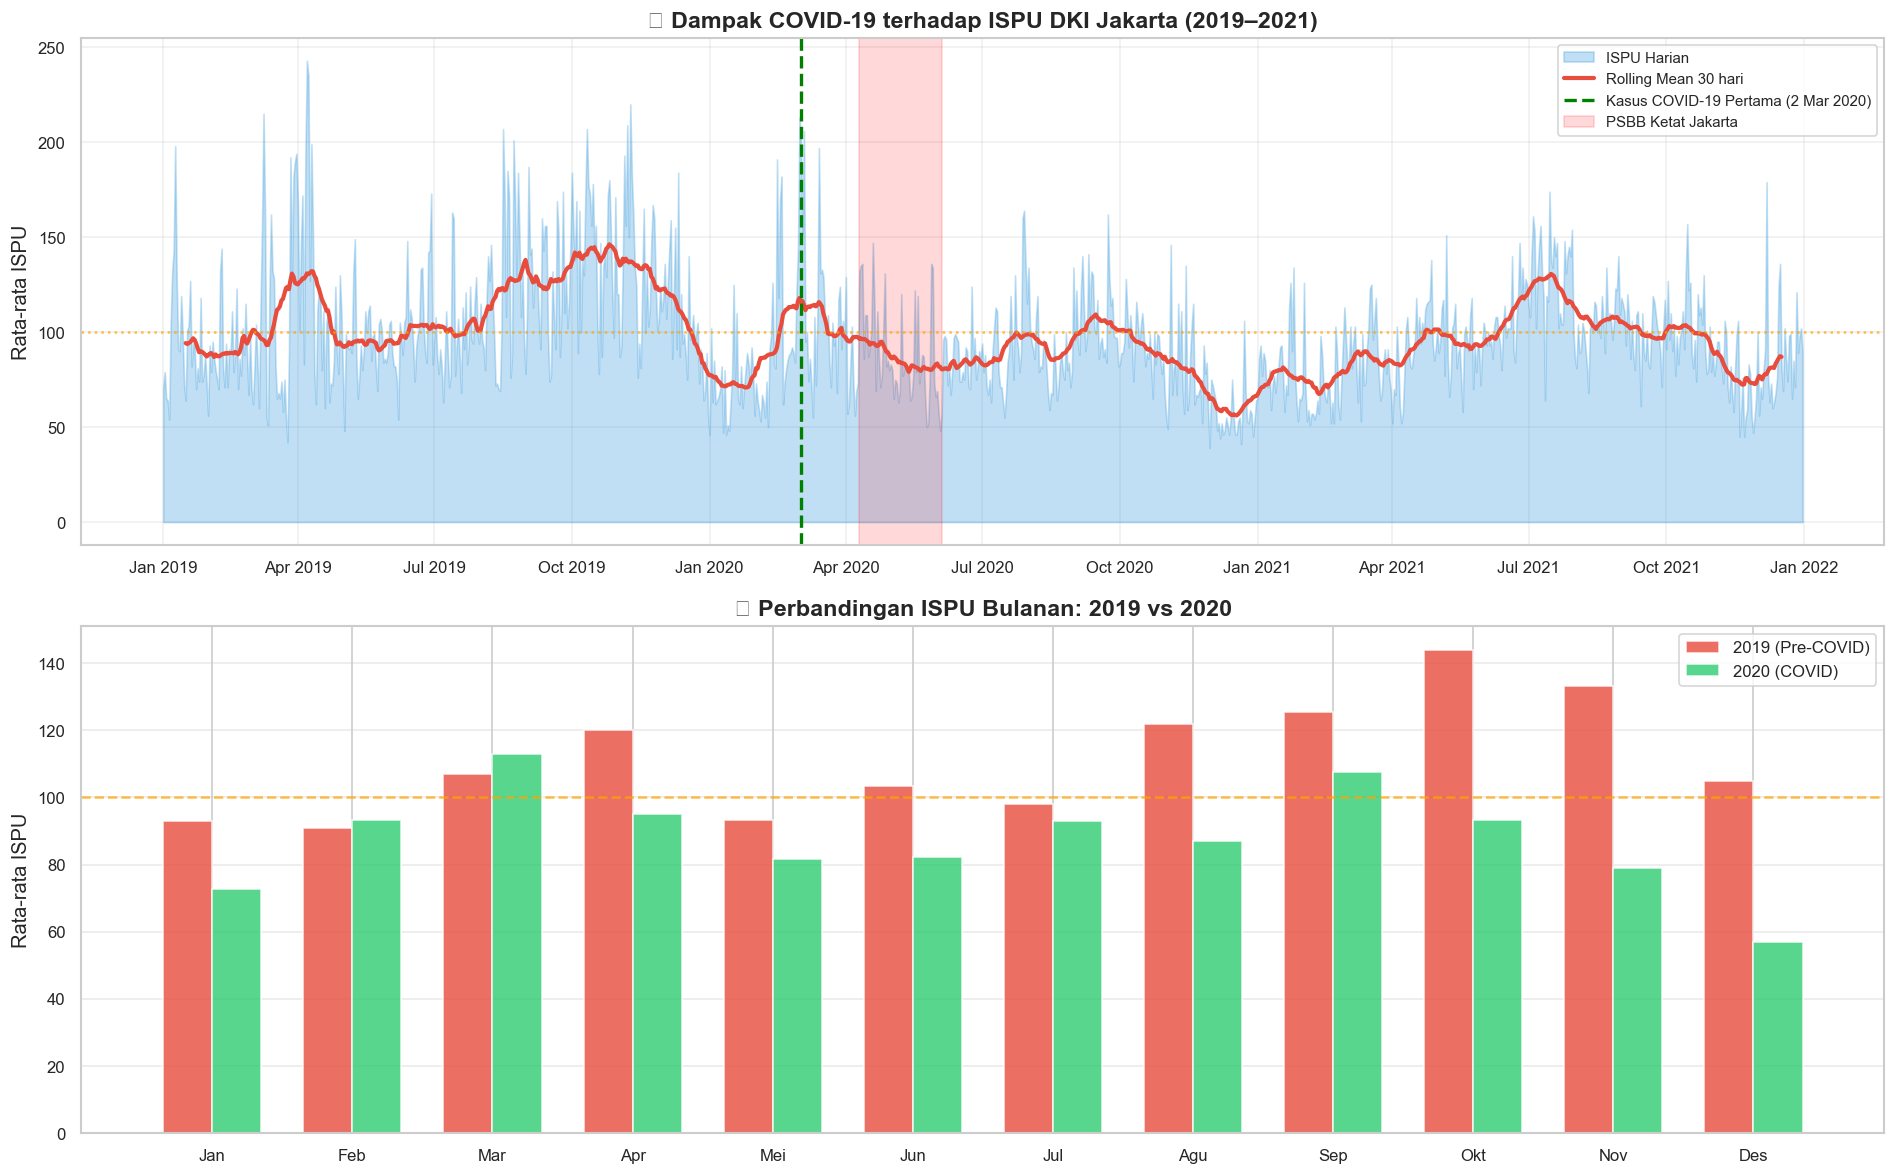


📝 INSIGHT COVID-19:
   • ISPU rata-rata Apr-Jun 2019 (pre-COVID): 105.5
   • ISPU rata-rata Apr-Jun 2020 (PSBB)     : 86.3
   • Penurunan ISPU selama PSBB             : 19.2 poin (18.2%)
   → Mobilitas berkurang drastis → emisi kendaraan turun → kualitas udara membaik sementara


In [58]:
# ── Analisis dampak COVID-19 ─────────────────────────────────────────────────
# Periode: PSBB ketat April-Mei 2020
df['tanggal'] = pd.to_datetime(df['tanggal'])
df_2019_2021 = df[df['year'].isin([2019, 2020, 2021])].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# --- Time series ISPU 2019-2021 ---
daily_2019_21 = df_2019_2021.groupby('tanggal')['ISPU_MAX'].mean().reset_index()
rolling_30 = daily_2019_21.set_index('tanggal')['ISPU_MAX'].rolling(30, center=True).mean()

axes[0].fill_between(daily_2019_21['tanggal'], daily_2019_21['ISPU_MAX'],
                     alpha=0.3, color='#3498db', label='ISPU Harian')
axes[0].plot(rolling_30.index, rolling_30.values, color='#e74c3c', linewidth=2.5,
             label='Rolling Mean 30 hari')
axes[0].axvline(pd.to_datetime('2020-03-02'), color='green', linestyle='--',
                linewidth=2, label='Kasus COVID-19 Pertama (2 Mar 2020)')
axes[0].axvspan(pd.to_datetime('2020-04-10'), pd.to_datetime('2020-06-04'),
                alpha=0.15, color='red', label='PSBB Ketat Jakarta')
axes[0].axhline(100, color='orange', linestyle=':', alpha=0.7)
axes[0].set_ylabel('Rata-rata ISPU')
axes[0].set_title('📉 Dampak COVID-19 terhadap ISPU DKI Jakarta (2019–2021)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# --- Rata-rata per bulan: 2019 vs 2020 ---
avg_2019 = df[df['year']==2019].groupby('month')['ISPU_MAX'].mean()
avg_2020 = df[df['year']==2020].groupby('month')['ISPU_MAX'].mean()

x = np.arange(1, 13)
w = 0.35
bars1 = axes[1].bar(x - w/2, avg_2019.reindex(x, fill_value=np.nan),
                     w, label='2019 (Pre-COVID)', color='#e74c3c', alpha=0.8)
bars2 = axes[1].bar(x + w/2, avg_2020.reindex(x, fill_value=np.nan),
                     w, label='2020 (COVID)', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
axes[1].set_ylabel('Rata-rata ISPU')
axes[1].set_title('📊 Perbandingan ISPU Bulanan: 2019 vs 2020', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)
axes[1].axhline(100, color='orange', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n📝 INSIGHT COVID-19:")
psbb_months = [4, 5, 6]
pre_covid  = df[(df['year']==2019) & (df['month'].isin(psbb_months))]['ISPU_MAX'].mean()
covid_psbb = df[(df['year']==2020) & (df['month'].isin(psbb_months))]['ISPU_MAX'].mean()
print(f"   • ISPU rata-rata Apr-Jun 2019 (pre-COVID): {pre_covid:.1f}")
print(f"   • ISPU rata-rata Apr-Jun 2020 (PSBB)     : {covid_psbb:.1f}")
print(f"   • Penurunan ISPU selama PSBB             : {pre_covid - covid_psbb:.1f} poin ({(pre_covid-covid_psbb)/pre_covid*100:.1f}%)")
print("   → Mobilitas berkurang drastis → emisi kendaraan turun → kualitas udara membaik sementara")

## 3.9 Ringkasan EDA & Key Takeaways

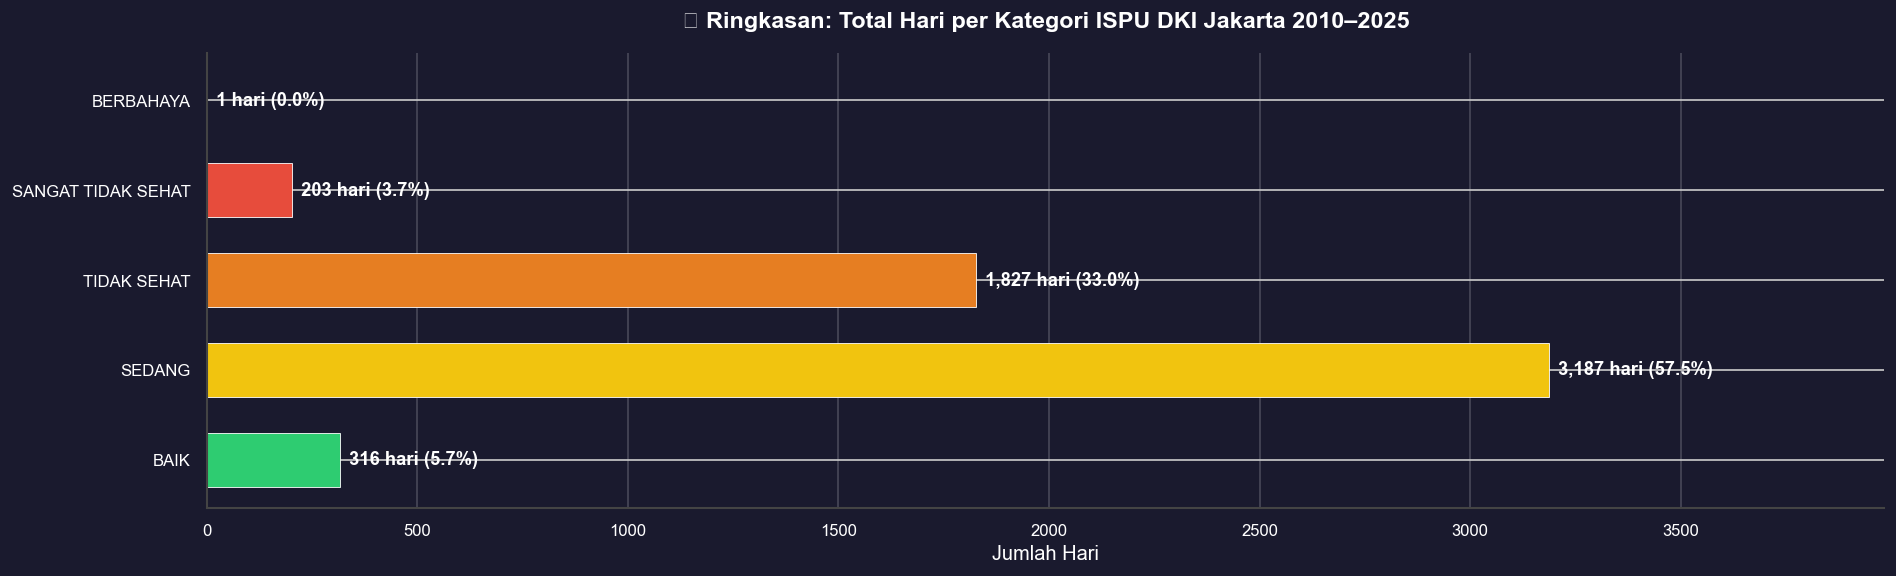


  📌 KEY TAKEAWAYS — DATA UNDERSTANDING & EDA

  1️⃣  DATASET: 5,538 observasi (2010–2025), 5 stasiun, 6 polutan + ISPU max

  2️⃣  KUALITAS DATA:
      • PM2.5 memiliki 72.6% missing value → perlu strategi khusus
      • Polutan lain (PM10, SO2, CO, O3, NO2) relatif lengkap (<6% missing)

  3️⃣  KONDISI UDARA:
      • 2,031 hari (36.7%) dengan kualitas TIDAK SEHAT atau lebih buruk
      • Hanya 316 hari (5.7%) dengan kualitas BAIK

  4️⃣  POLUTAN DOMINAN:
      • O₃ (Ozon) paling sering menjadi polutan kritis (reaksi fotokimia)
      • PM2.5 menjadi ancaman utama kesehatan (penetrasi paru-paru dalam)

  5️⃣  POLA TEMPORAL:
      • Musim Kemarau (Apr-Sep) konsisten lebih buruk dari Musim Hujan
      • Pandemi COVID-2020 menurunkan ISPU rata-rata selama PSBB

  6️⃣  SPASIAL:
      • Terdapat perbedaan kualitas udara antar stasiun
      • Perlu analisis lebih lanjut per wilayah untuk kebijakan targeted

  7️⃣  REKOMENDASI NEXT STEPS:
      ✅ Handling missing value PM2.5 (forward-fill / i

In [59]:
# ── Final Summary Dashboard ───────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')

categories_for_summary = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
counts_for_summary = [df['kategori'].value_counts().get(c, 0) for c in categories_for_summary]
colors_for_summary = [ISPU_COLORS[c] for c in categories_for_summary]

ax = fig.add_subplot(111)
ax.set_facecolor('#1a1a2e')
bars = ax.barh(categories_for_summary, counts_for_summary, color=colors_for_summary,
               edgecolor='white', linewidth=0.5, height=0.6)
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('📋 Ringkasan: Total Hari per Kategori ISPU DKI Jakarta 2010–2025',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Jumlah Hari', color='white')

for bar, count in zip(bars, counts_for_summary):
    pct = count / len(df) * 100
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f' {count:,} hari ({pct:.1f}%)', va='center', color='white', fontsize=11, fontweight='bold')
ax.set_xlim(0, max(counts_for_summary) * 1.25)
ax.grid(axis='x', alpha=0.2, color='white')
plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("  📌 KEY TAKEAWAYS — DATA UNDERSTANDING & EDA")
print("=" * 70)
total = len(df)
unhealthy_total = df['kategori'].isin(['TIDAK SEHAT','SANGAT TIDAK SEHAT','BERBAHAYA']).sum()
print(f"""
  1️⃣  DATASET: {total:,} observasi (2010–2025), 5 stasiun, 6 polutan + ISPU max
  
  2️⃣  KUALITAS DATA:
      • PM2.5 memiliki 72.6% missing value → perlu strategi khusus
      • Polutan lain (PM10, SO2, CO, O3, NO2) relatif lengkap (<6% missing)
  
  3️⃣  KONDISI UDARA:
      • {unhealthy_total:,} hari ({unhealthy_total/total*100:.1f}%) dengan kualitas TIDAK SEHAT atau lebih buruk
      • Hanya {df['kategori'].value_counts().get('BAIK',0):,} hari ({df['kategori'].value_counts().get('BAIK',0)/total*100:.1f}%) dengan kualitas BAIK
  
  4️⃣  POLUTAN DOMINAN:
      • O₃ (Ozon) paling sering menjadi polutan kritis (reaksi fotokimia)
      • PM2.5 menjadi ancaman utama kesehatan (penetrasi paru-paru dalam)
  
  5️⃣  POLA TEMPORAL:
      • Musim Kemarau (Apr-Sep) konsisten lebih buruk dari Musim Hujan
      • Pandemi COVID-2020 menurunkan ISPU rata-rata selama PSBB
  
  6️⃣  SPASIAL:
      • Terdapat perbedaan kualitas udara antar stasiun
      • Perlu analisis lebih lanjut per wilayah untuk kebijakan targeted
  
  7️⃣  REKOMENDASI NEXT STEPS:
      ✅ Handling missing value PM2.5 (forward-fill / interpolasi / model imputation)
      ✅ Feature engineering tambahan (lag features, rolling statistics)  
      ✅ Modeling: Time-series forecasting ISPU harian
      ✅ Modeling: Klasifikasi kategori ISPU multi-class
      ✅ Analisis spasial dengan peta interaktif DKI Jakarta
""")
print("=" * 70)